# Simulation results analysis — MPM only

Reads `Input_Results_redo.csv`. All plots use the corrected MPM `|MPM - Mean|`.

1. Per Hs pair: MPM vs Tp, 3 DOFs, averaged over directions, one line per damping case.
2. Per Hs pair: MPM vs Tp, 3 DOFs, low damping only, one line per direction.
3. Per Hs: % MPM difference vs `low`, 3 DOFs side by side.
4. Damping effectiveness vs Hs, averaged over Tp and direction.
5. Damping effectiveness vs Tp, averaged over Hs and direction.
6. Direct linhigh-vs-quadhigh comparison vs Hs and vs Tp.
7. `average` damping vs low, linhigh and quadhigh (3 DOFs × 3 alternatives).

In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

TITLE_SIZE = 18
LABEL_SIZE = 16
TICK_SIZE = 14

plt.rcParams.update({
    'axes.titlesize': TITLE_SIZE,
    'axes.labelsize': LABEL_SIZE,
    'xtick.labelsize': TICK_SIZE,
    'ytick.labelsize': TICK_SIZE,
    'legend.fontsize': TICK_SIZE,
    'figure.titlesize': TITLE_SIZE,
})

In [3]:
df = pd.read_csv('Simulation_output_redo.csv')

for col in ['Damp_Heave', 'Damp_Roll', 'Damp_Pitch']:
    df[col] = df[col].replace({'DOFbest': 'average'})

for suffix in ['Z', 'pitch', 'roll']:
    df[f'MPM {suffix} corr'] = (df[f'MPM {suffix}'] - df[f'Mean {suffix}']).abs()

DOFS = [
    {'key': 'Z',     'name': 'Heave', 'unit': 'm',   'drop_dirs': []},
    {'key': 'pitch', 'name': 'Pitch', 'unit': 'deg', 'drop_dirs': []},
    {'key': 'roll',  'name': 'Roll',  'unit': 'deg', 'drop_dirs': [0, 180]},
]

DAMPING_CASES = ['low', 'linhigh', 'quadhigh', 'average']
DAMPING_COLORS = {
    'low':      '#1f77b4',
    'linhigh':  '#ff7f0e',
    'quadhigh': '#2ca02c',
    'average':  '#d62728',
}

HS_VALUES = sorted(df['Hs'].unique())
DIRECTIONS = sorted(df['Direction'].unique())

def damping_col(dof_key):
    return {'Z': 'Damp_Heave', 'pitch': 'Damp_Pitch', 'roll': 'Damp_Roll'}[dof_key]

def filter_dirs(sub, dof):
    if dof['drop_dirs']:
        sub = sub[~sub['Direction'].isin(dof['drop_dirs'])]
    return sub

def hs_pairs(values):
    """Group Hs values into pairs of 2 for side-by-side plotting."""
    return [values[i:i+2] for i in range(0, len(values), 2)]

# Groups of Hs values plotted side by side. Hs 4, 6, 8 share a figure;
# the higher-Hs subplots are narrower because they only span Tp 9-12.
HS_GROUPS = [[1, 2], [4, 6, 8]]

def tp_count(df, hs):
    """Number of distinct Tp values for this Hs (drives subplot width)."""
    return df[df['Hs'] == hs]['Tp'].nunique()

print('Hs values:', HS_VALUES)
print('Directions:', DIRECTIONS)

df.head(10)

Hs values: [np.int64(1), np.int64(2), np.int64(4), np.int64(6), np.int64(8)]
Directions: [np.int64(0), np.int64(45), np.int64(90), np.int64(135), np.int64(180)]


,filename,Hs,Tp,Tz,Direction,Damp_Heave,Damp_Roll,Damp_Pitch,Lin_Heave,Quad_Heave,...,MPM roll,Mean velocity Z,Mean velocity pitch,Mean velocity roll,std velocity Z,std velocity pitch,std velocity roll,MPM Z corr,MPM pitch corr,MPM roll corr
0,ymlfiles\Case_001_H1_T3p5_dir0_heavelow_pitchl...,1,3.5,2.7132,0,low,low,low,1.0,1.0,...,-0.001673,0.000204,1.359449e-06,1.022967e-09,0.026532,0.021246,0.000002,0.059950,2.706451,0.000658
1,ymlfiles\Case_002_H1_T3p5_dir0_heavelinhigh_pi...,1,3.5,2.7132,0,linhigh,linhigh,linhigh,6.5,1.0,...,-0.001730,0.000183,1.356389e-06,9.104538e-10,0.026206,0.021172,0.000002,0.058644,2.695492,0.000602
2,ymlfiles\Case_003_H1_T3p5_dir0_heavequadhigh_p...,1,3.5,2.7132,0,quadhigh,quadhigh,quadhigh,1.0,4.0,...,-0.001674,0.000200,1.355888e-06,1.090954e-09,0.026533,0.021231,0.000002,0.059962,2.704141,0.000657
3,ymlfiles\Case_004_H1_T3p5_dir0_heaveDOFbest_pi...,1,3.5,2.7132,0,average,average,average,3.3,2.4,...,-0.001712,0.000191,1.356233e-06,9.518392e-10,0.026401,0.021199,0.000002,0.059426,2.699423,0.000619
4,ymlfiles\Case_005_H1_T3p5_dir45_heavelow_pitch...,1,3.5,2.7132,45,low,low,low,1.0,1.0,...,1.411232,0.000165,4.885577e-05,4.245085e-05,0.018765,0.009632,0.010678,0.045706,1.244906,1.406902
5,ymlfiles\Case_006_H1_T3p5_dir45_heavelinhigh_p...,1,3.5,2.7132,45,linhigh,linhigh,linhigh,6.5,1.0,...,1.404928,0.000153,4.877374e-05,4.247219e-05,0.018434,0.009599,0.010642,0.044424,1.238581,1.400572
6,ymlfiles\Case_007_H1_T3p5_dir45_heavequadhigh_...,1,3.5,2.7132,45,quadhigh,quadhigh,quadhigh,1.0,4.0,...,1.410655,0.000164,4.884903e-05,4.245331e-05,0.018762,0.009629,0.010675,0.045690,1.244297,1.406327
7,ymlfiles\Case_008_H1_T3p5_dir45_heaveDOFbest_p...,1,3.5,2.7132,45,average,average,average,3.3,2.4,...,1.406980,0.000157,4.880525e-05,4.246486e-05,0.018627,0.009612,0.010654,0.045163,1.241048,1.402624
8,ymlfiles\Case_009_H1_T3p5_dir90_heavelow_pitch...,1,3.5,2.7132,90,low,low,low,1.0,1.0,...,0.880778,0.000008,-6.102355e-07,-1.521778e-05,0.013314,0.002928,0.007770,0.031775,0.456784,0.880921
9,ymlfiles\Case_010_H1_T3p5_dir90_heavelinhigh_p...,1,3.5,2.7132,90,linhigh,linhigh,linhigh,6.5,1.0,...,0.876466,0.000005,-1.038026e-06,-1.501481e-05,0.013022,0.002896,0.007748,0.030546,0.445598,0.876585


## 1. MPM vs Tp, averaged over directions — Hs grouped (4,6,8 share a figure)

3 rows (DOFs) × 2 columns (Hs), one line per damping case.

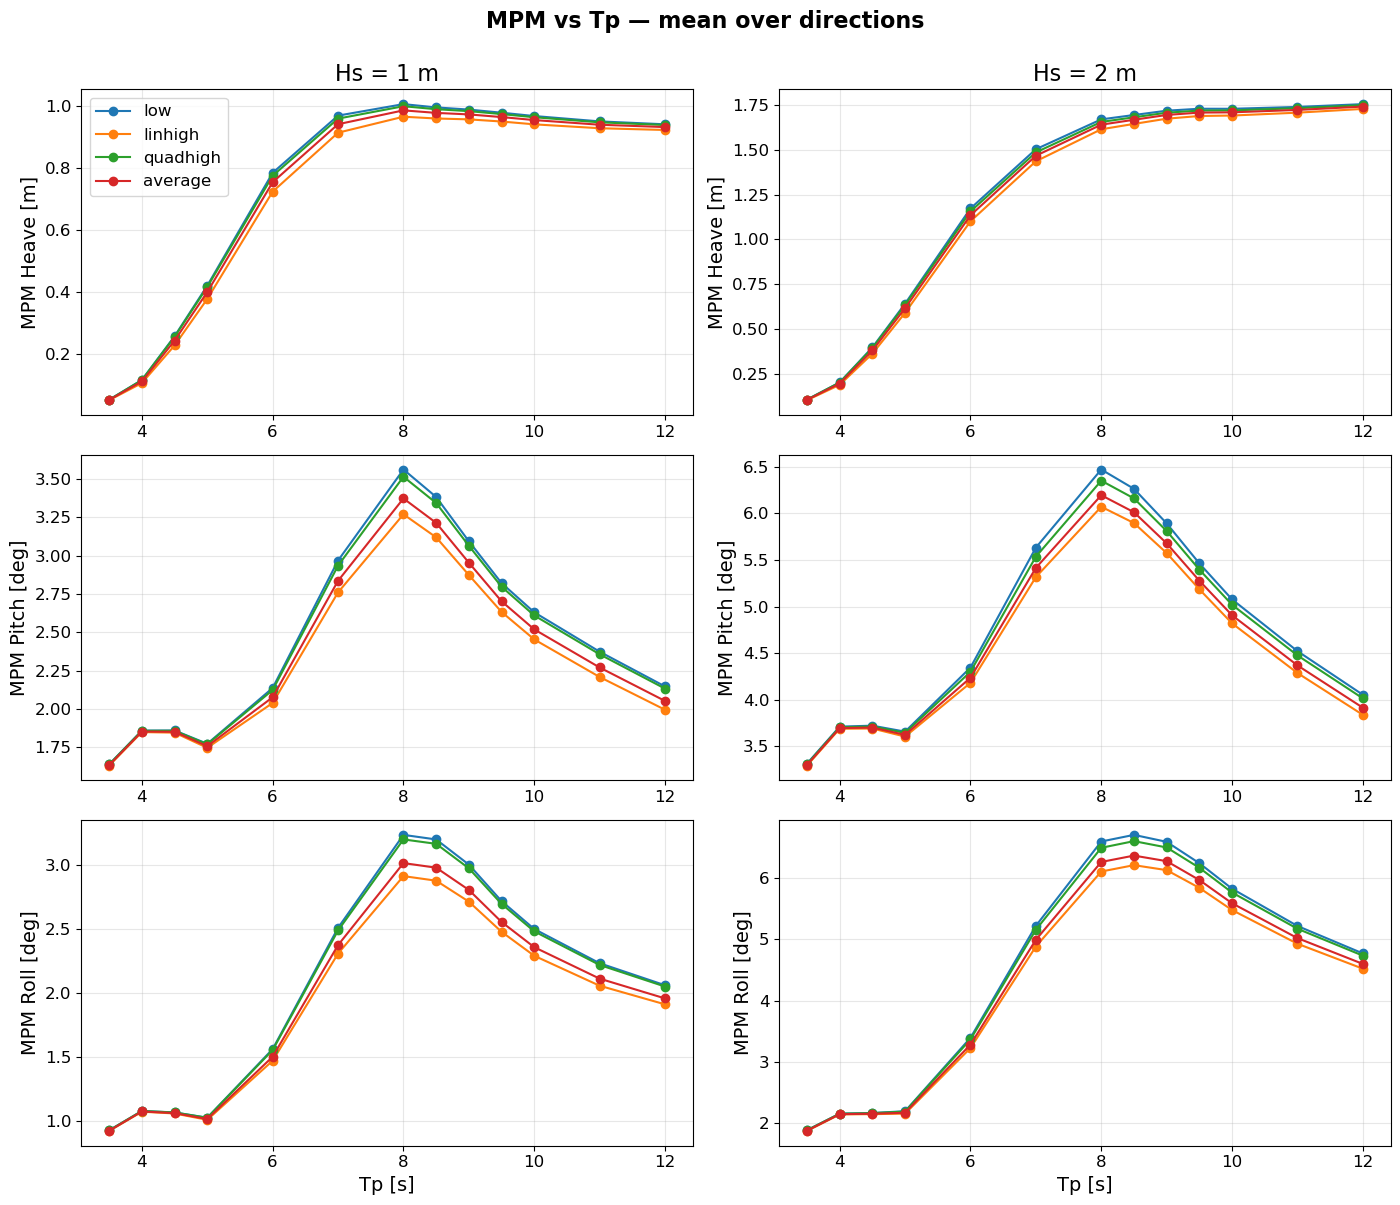

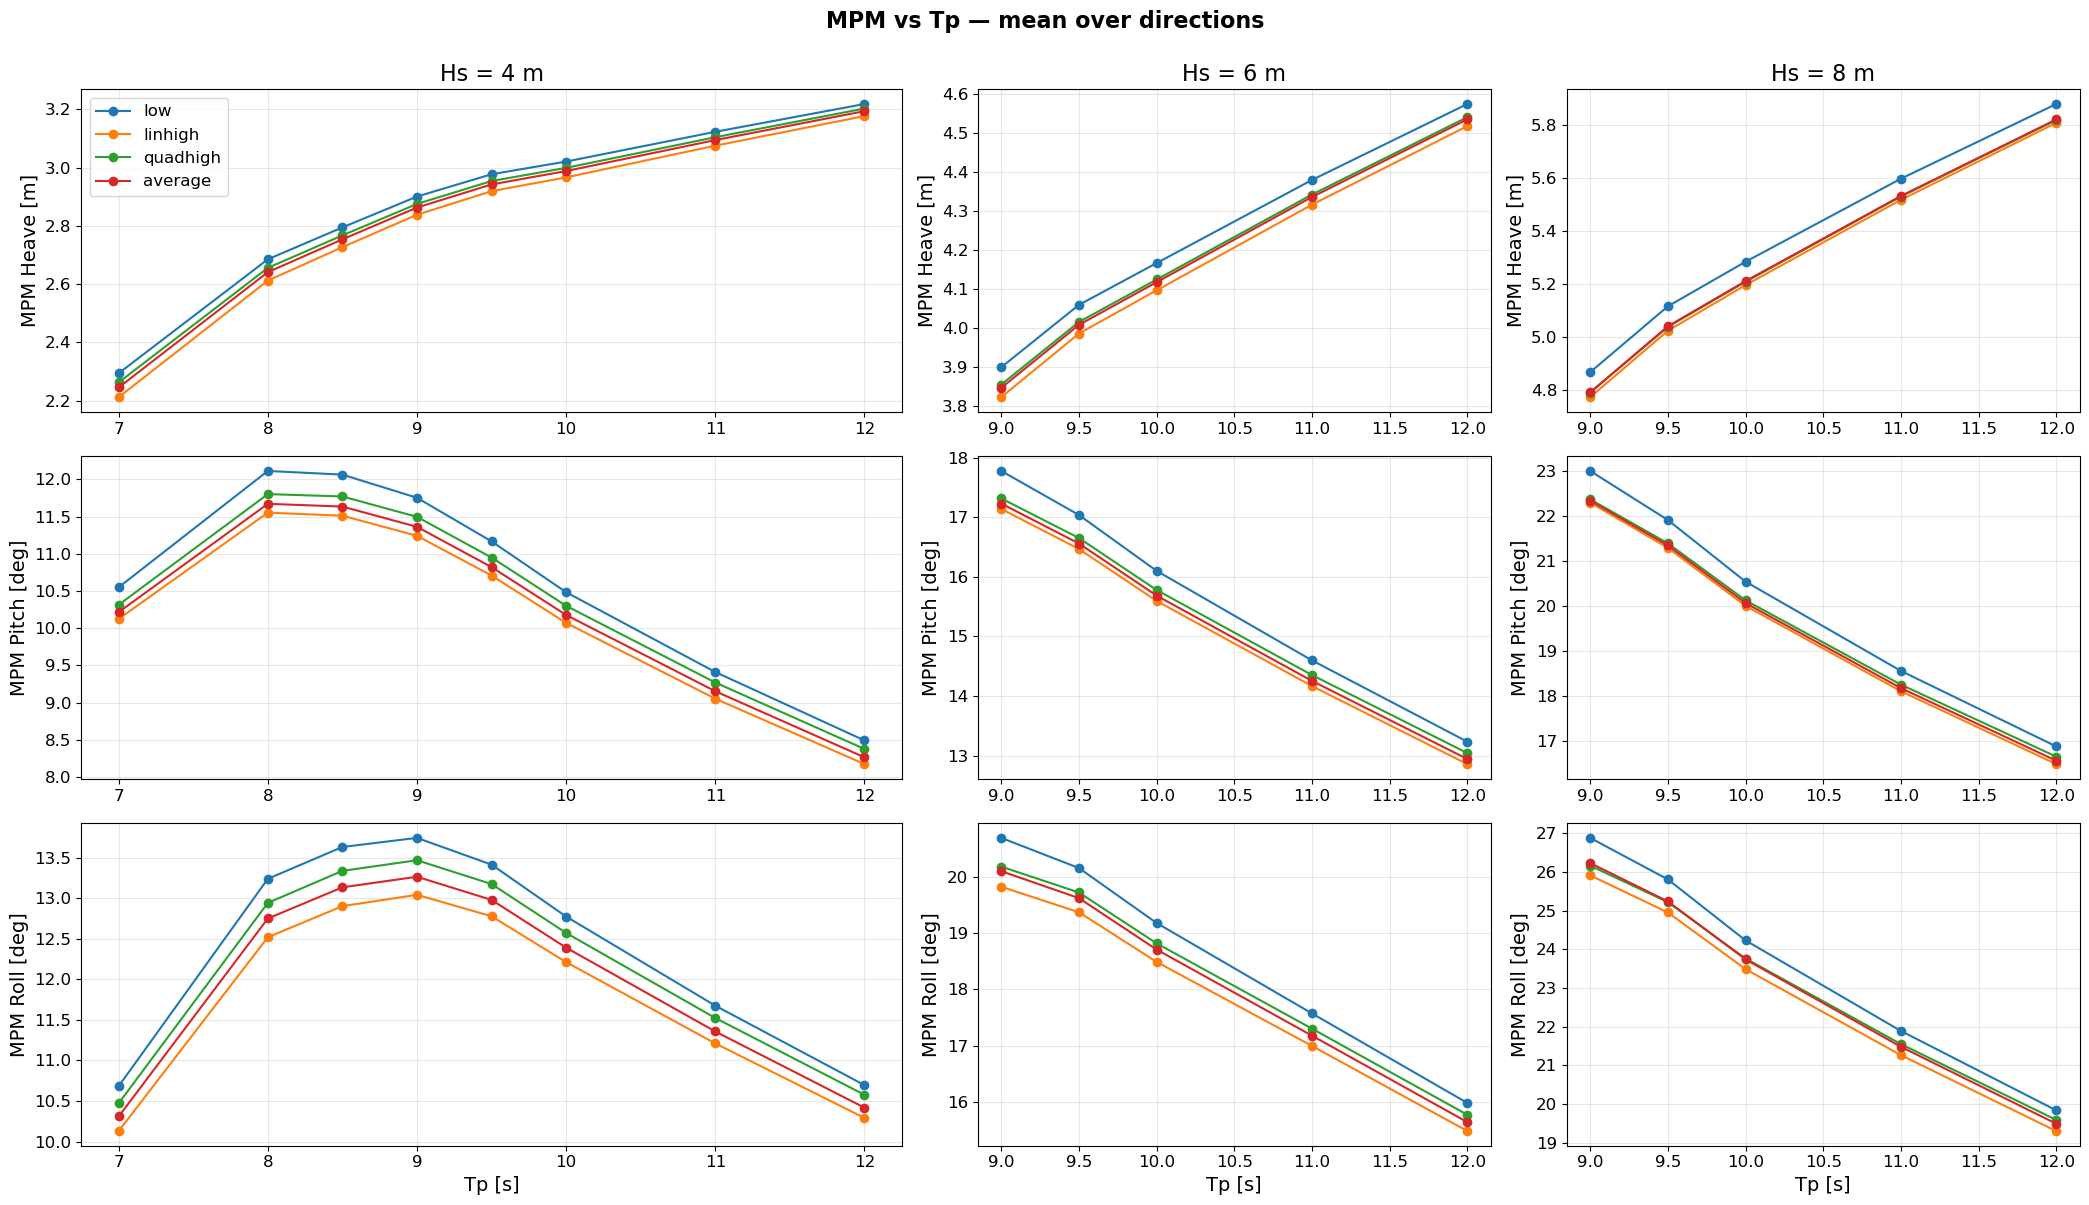

In [4]:
for group in HS_GROUPS:
    ncols = len(group)
    widths = [tp_count(df, hs) for hs in group]
    fig, axes = plt.subplots(3, ncols, figsize=(7*ncols, 12),
                             squeeze=False,
                             gridspec_kw={'width_ratios': widths})

    for c, hs in enumerate(group):
        sub_hs = df[df['Hs'] == hs]
        for r, dof in enumerate(DOFS):
            sub_dof = filter_dirs(sub_hs, dof)
            dcol = damping_col(dof['key'])
            mpm_c = f'MPM {dof["key"]} corr'
            ax = axes[r, c]

            for case in DAMPING_CASES:
                sub_case = sub_dof[sub_dof[dcol] == case]
                if sub_case.empty:
                    continue
                grouped = sub_case.groupby('Tp')[mpm_c].mean().sort_index()
                ax.plot(grouped.index, grouped.values, 'o-',
                        label=case, color=DAMPING_COLORS[case])

            ax.grid(True, alpha=0.3)
            ax.tick_params(axis='both', labelsize=TICK_SIZE)
            ax.set_ylabel(f'MPM {dof["name"]} [{dof["unit"]}]', fontsize=LABEL_SIZE)
            if r == 0:
                ax.set_title(f'Hs = {hs} m', fontsize=TITLE_SIZE)
            if r == 0 and c == 0:
                ax.legend(fontsize=TICK_SIZE)
            if r == 2:
                ax.set_xlabel('Tp [s]', fontsize=LABEL_SIZE)

    fig.suptitle('MPM vs Tp — mean over directions', y=1.00, fontweight='bold')
    fig.tight_layout()
plt.show()

## 2. MPM vs Tp per direction (low damping only) — Hs grouped

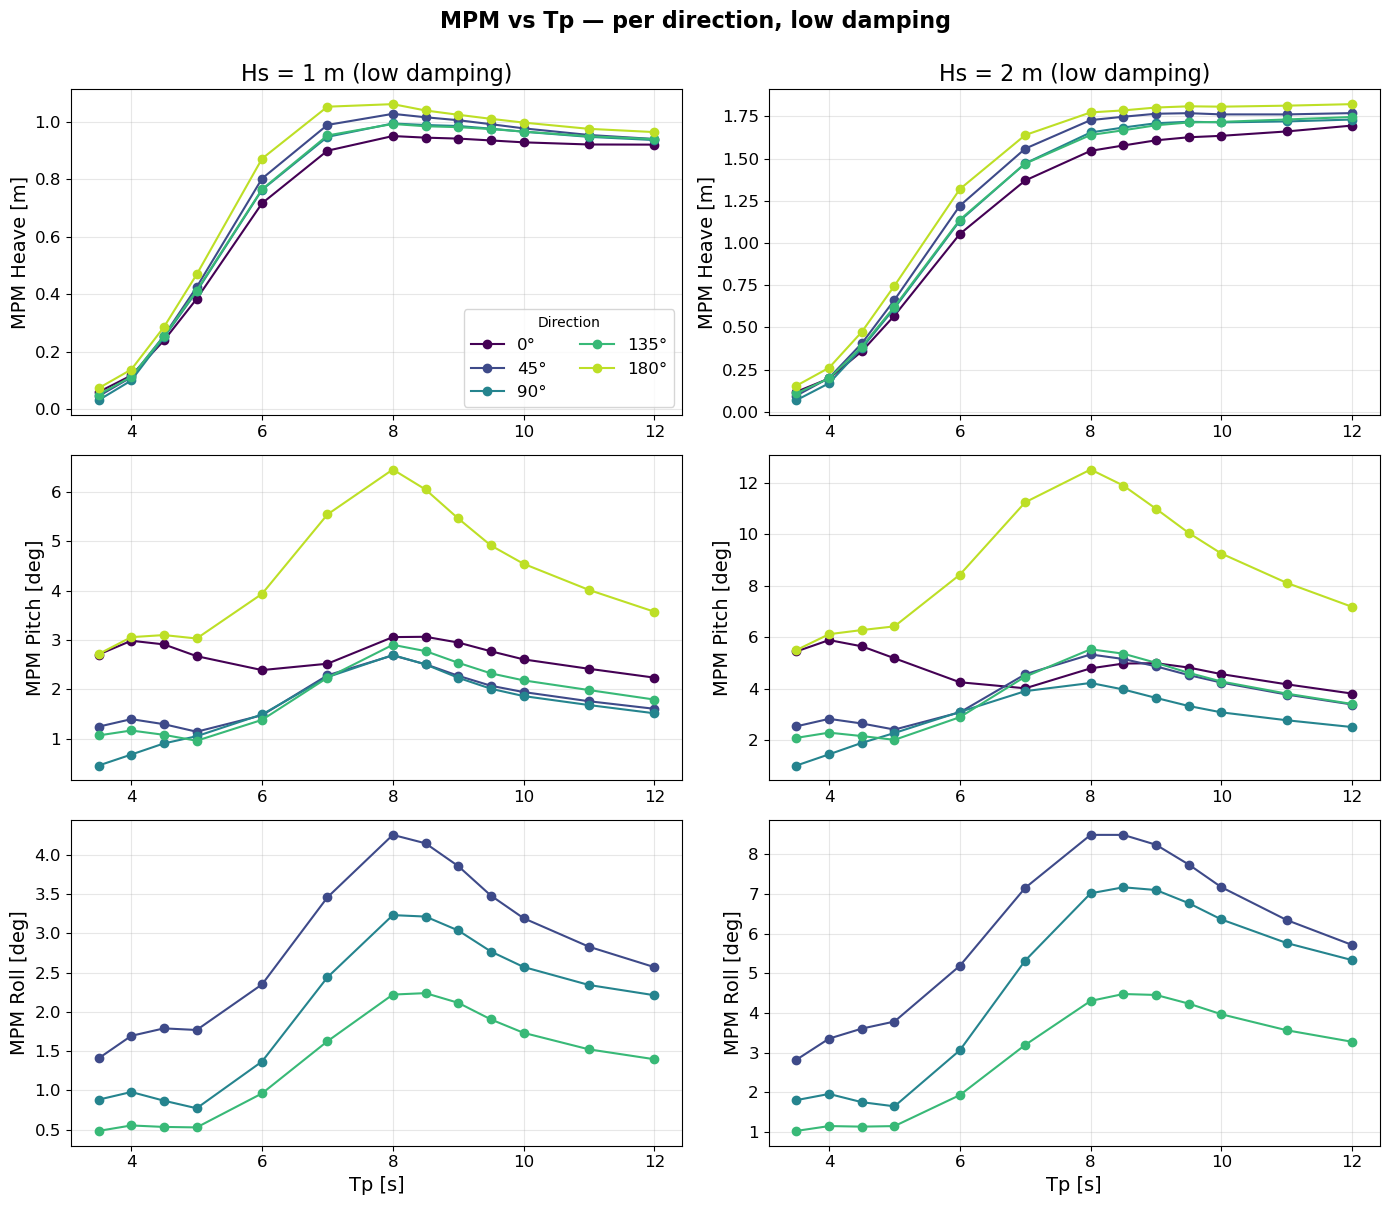

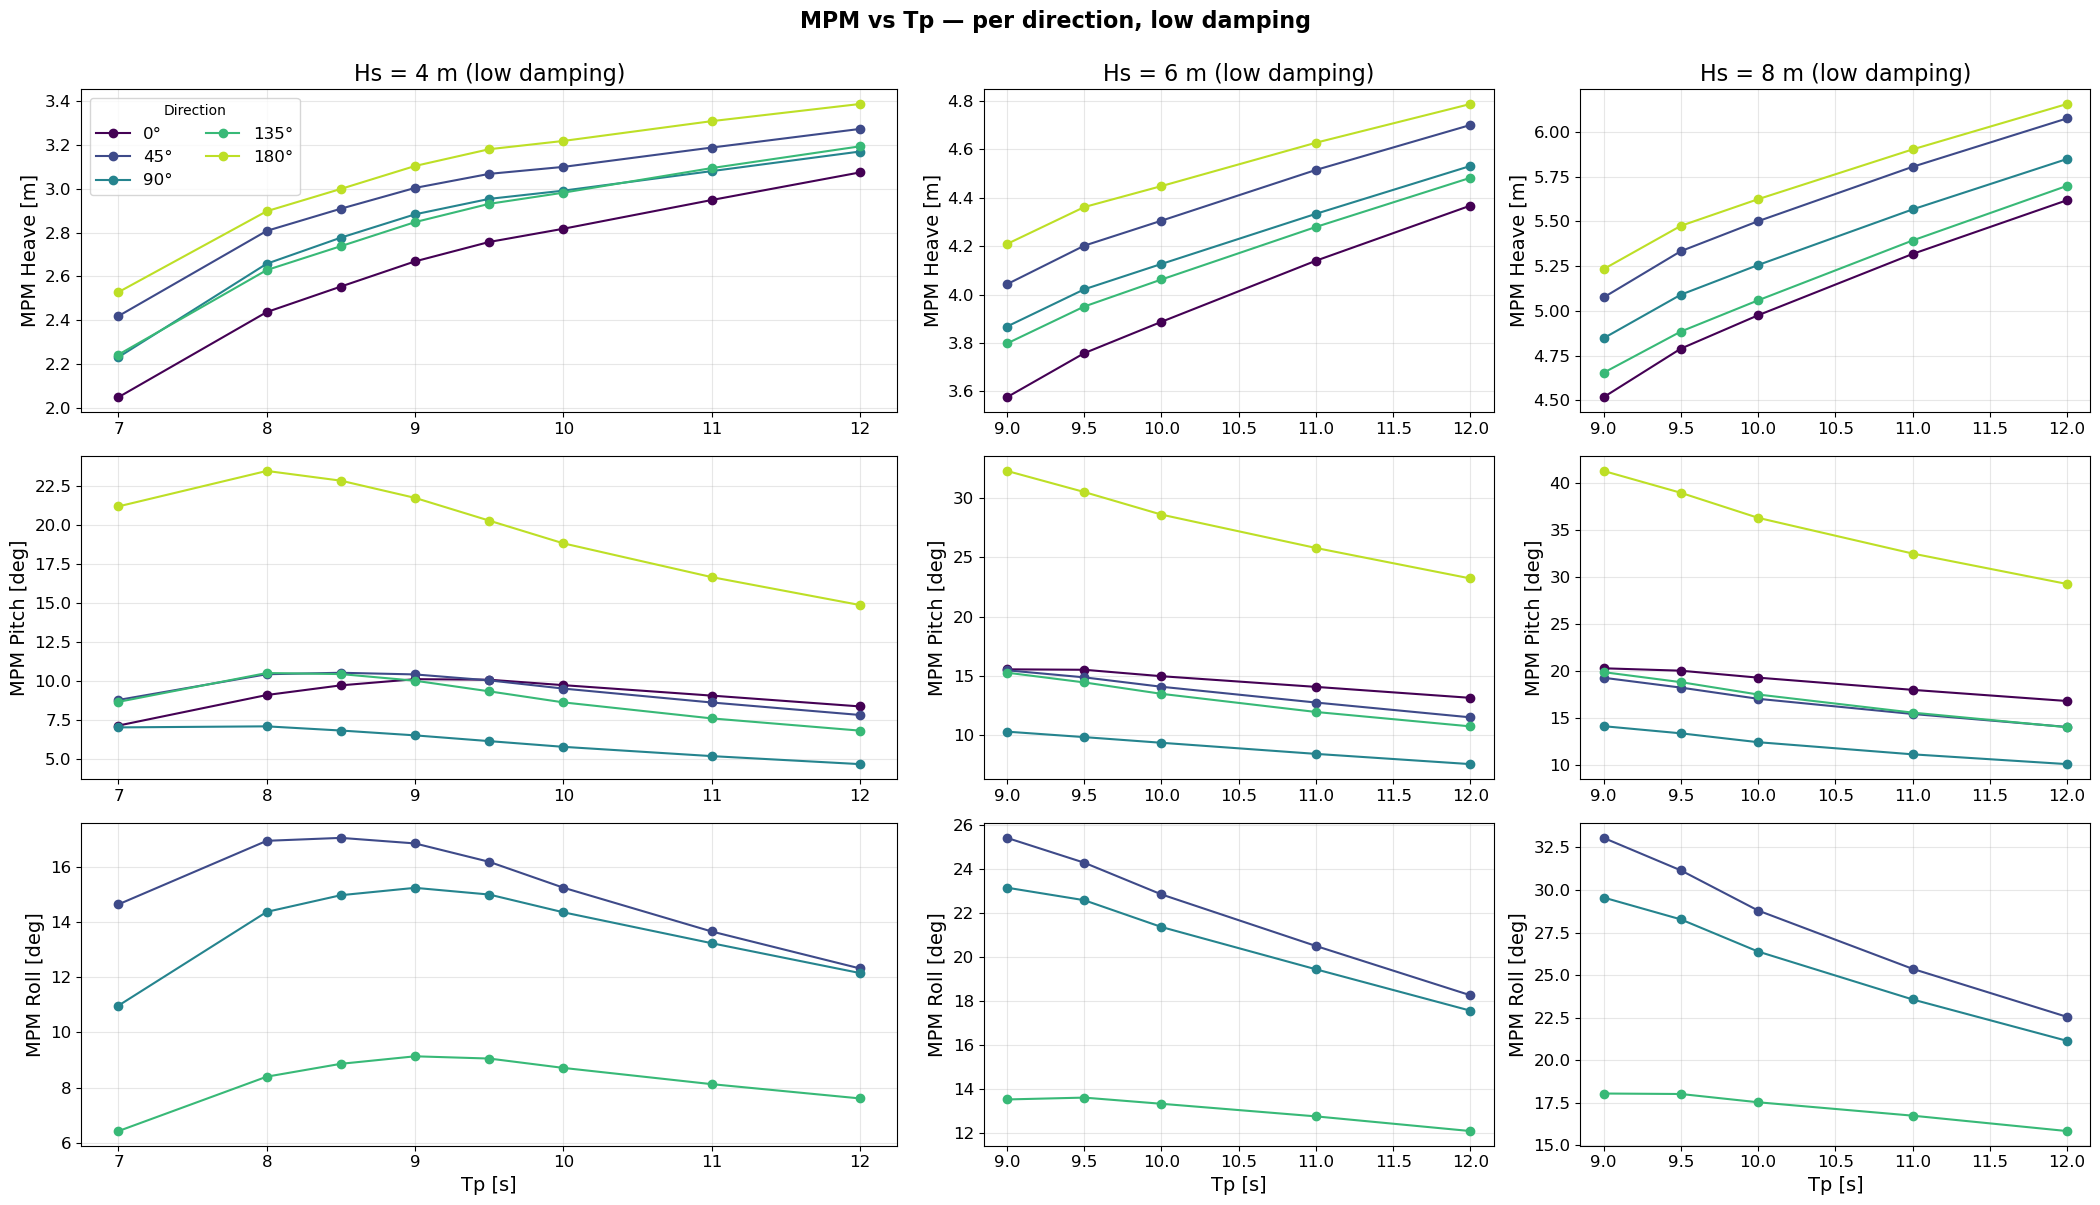

In [5]:
DIR_COLORS = plt.cm.viridis(np.linspace(0, 0.9, len(DIRECTIONS)))

for group in HS_GROUPS:
    ncols = len(group)
    widths = [tp_count(df, hs) for hs in group]
    fig, axes = plt.subplots(3, ncols, figsize=(7*ncols, 12),
                             squeeze=False,
                             gridspec_kw={'width_ratios': widths})

    for c, hs in enumerate(group):
        sub_hs = df[(df['Hs'] == hs) & (df['Damp_Heave'] == 'low')]
        for r, dof in enumerate(DOFS):
            sub_dof = filter_dirs(sub_hs, dof)
            mpm_c = f'MPM {dof["key"]} corr'
            ax = axes[r, c]

            for d, direction in enumerate(DIRECTIONS):
                sub_dir = sub_dof[sub_dof['Direction'] == direction].sort_values('Tp')
                if sub_dir.empty:
                    continue
                ax.plot(sub_dir['Tp'], sub_dir[mpm_c], 'o-',
                        label=f'{direction}°', color=DIR_COLORS[d])

            ax.grid(True, alpha=0.3)
            ax.tick_params(axis='both', labelsize=TICK_SIZE)
            ax.set_ylabel(f'MPM {dof["name"]} [{dof["unit"]}]', fontsize=LABEL_SIZE)
            if r == 0:
                ax.set_title(f'Hs = {hs} m (low damping)', fontsize=TITLE_SIZE)
            if r == 0 and c == 0:
                ax.legend(title='Direction', ncol=2, fontsize=TICK_SIZE)
            if r == 2:
                ax.set_xlabel('Tp [s]', fontsize=LABEL_SIZE)

    fig.suptitle('MPM vs Tp — per direction, low damping', y=1.00, fontweight='bold')
    fig.tight_layout()
plt.show()

## 3. Percentage difference vs the `low` case (per Hs)

Computed as `(case − low) / low × 100%` per Tp, after averaging over directions. The `low` case itself is the baseline and is not drawn.

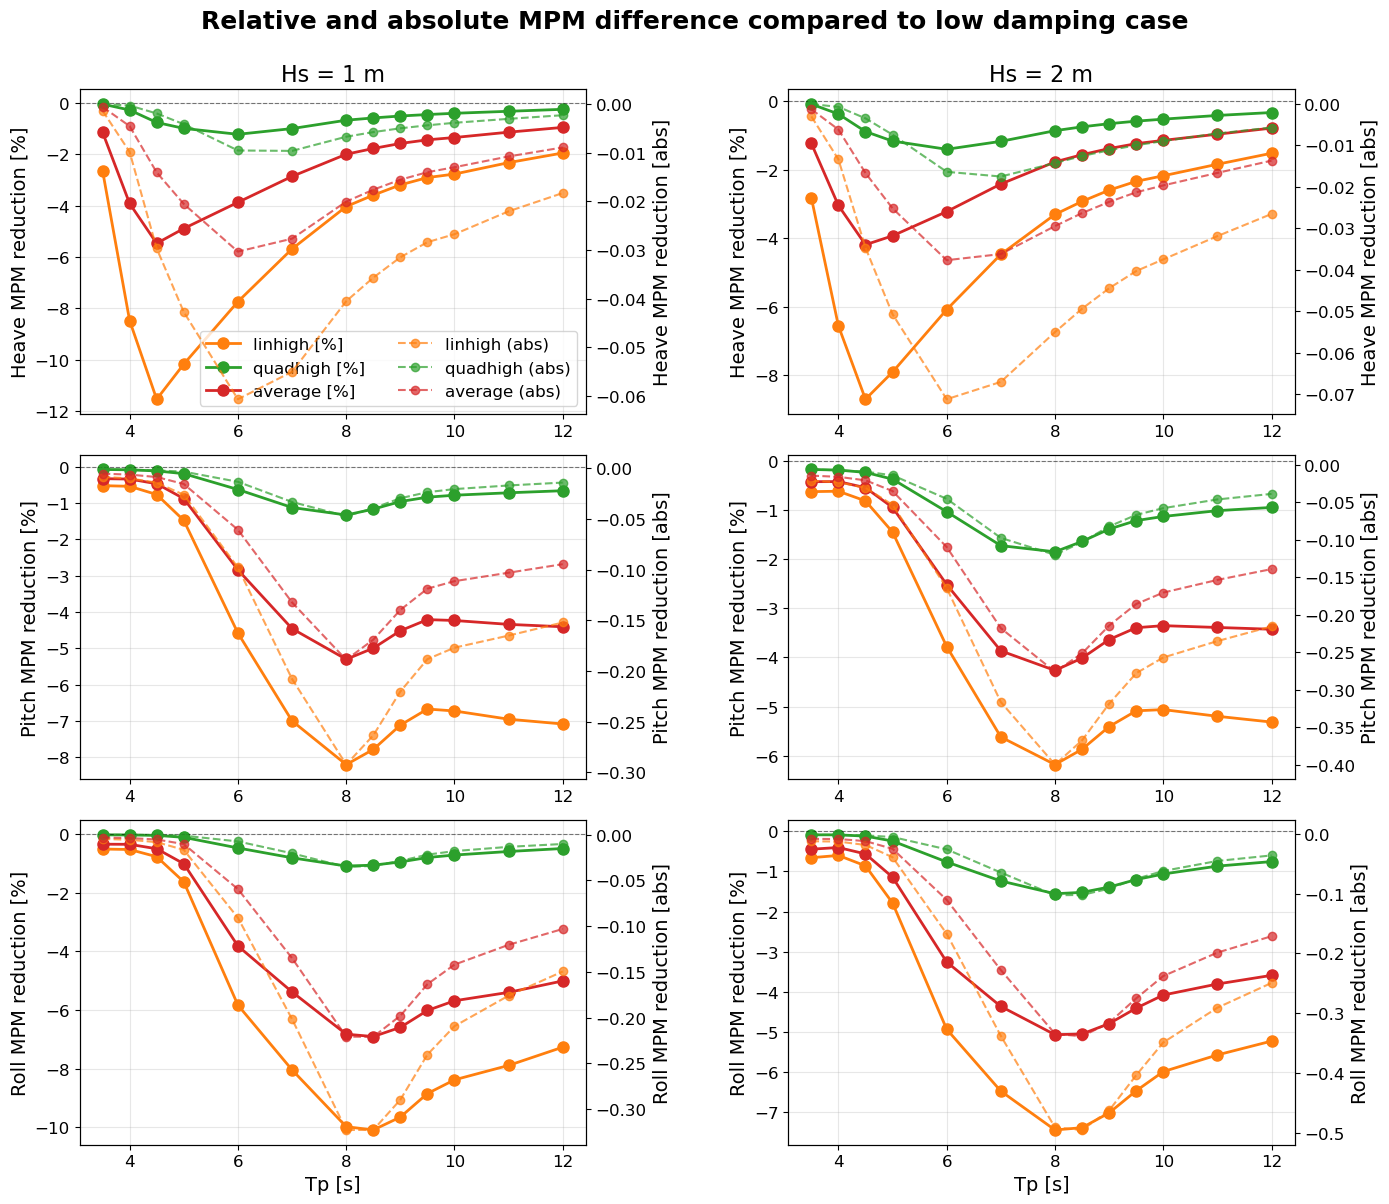

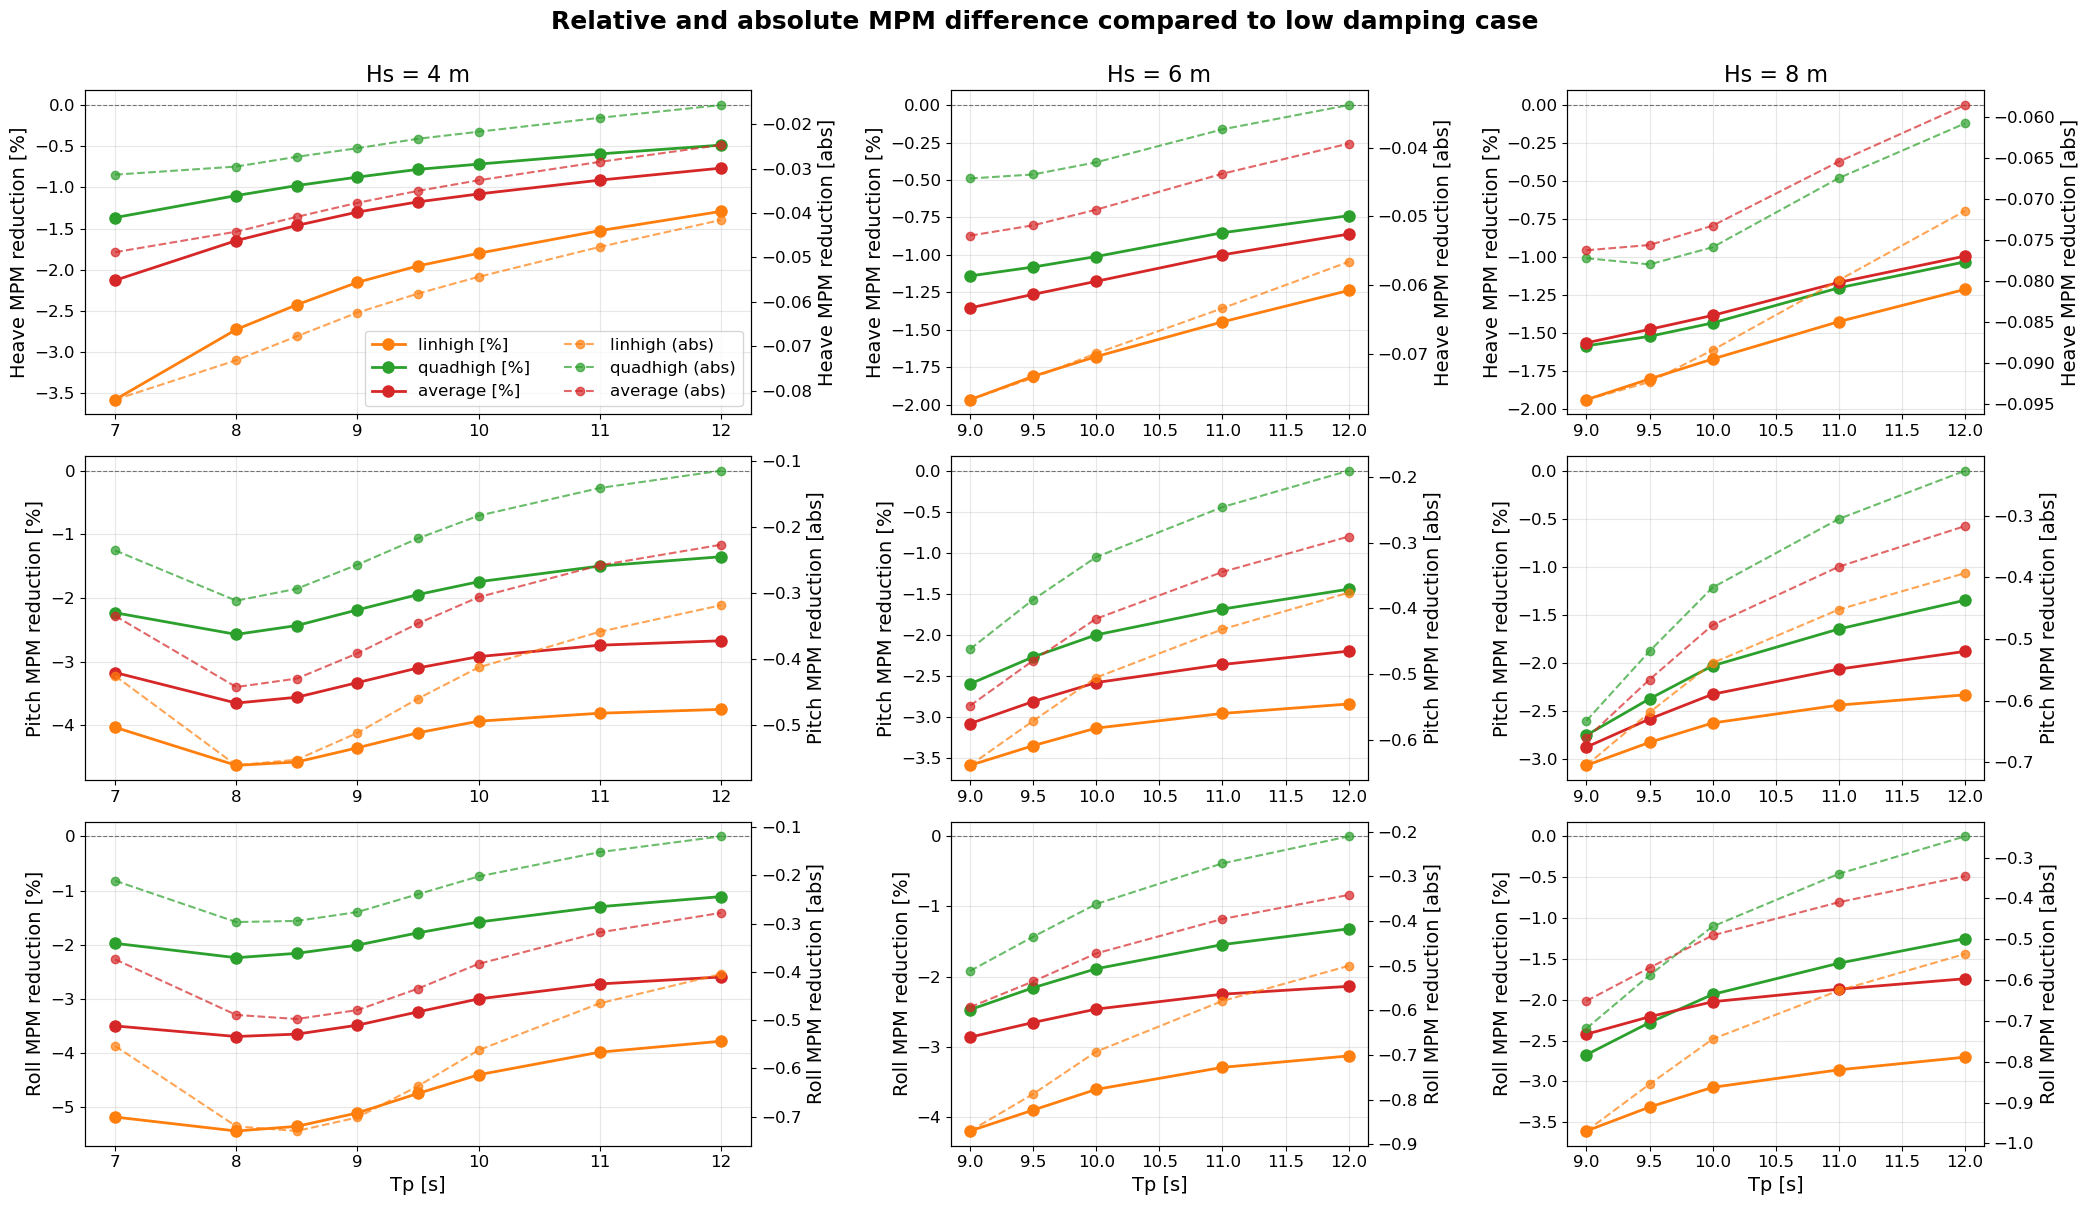

In [36]:
def plot_pct_diff_group(df, group):
    ncols = len(group)
    widths = [tp_count(df, hs) for hs in group]
    fig, axes = plt.subplots(3, ncols, figsize=(7*ncols, 12),
                             squeeze=False,
                             gridspec_kw={'width_ratios': widths})

    for c, hs in enumerate(group):
        sub_hs = df[df['Hs'] == hs]
        for r, dof in enumerate(DOFS):
            ax = axes[r, c]          # left y-axis: relative difference [%]
            ax2 = ax.twinx()         # right y-axis: absolute difference
            sub_dof = filter_dirs(sub_hs, dof)
            dcol = damping_col(dof['key'])
            mpm_c = f'MPM {dof["key"]} corr'

            base = sub_dof[sub_dof[dcol] == 'low'].groupby('Tp')[mpm_c].mean().sort_index()

            for case in ['linhigh', 'quadhigh', 'average']:
                sub_case = sub_dof[sub_dof[dcol] == case]
                if sub_case.empty:
                    continue
                grouped = sub_case.groupby('Tp')[mpm_c].mean().sort_index()
                common = grouped.index.intersection(base.index)
                if len(common) == 0:
                    continue

                diff_abs = grouped.loc[common] - base.loc[common]              # absolute difference
                pct = diff_abs / base.loc[common] * 100                        # relative difference

                # relative on left axis
                ax.plot(common, pct, 'o-', label=f'{case} [%]',
                        color=DAMPING_COLORS[case], linewidth=2, markersize=8)

                # absolute on right axis
                ax2.plot(common, diff_abs, 'o--', label=f'{case} (abs)',
                         color=DAMPING_COLORS[case], linewidth=1.5,
                         markersize=6, alpha=0.7)

            ax.axhline(0, color='black', lw=0.8, ls='--', alpha=0.5)
            ax.grid(True, alpha=0.3)
            ax.tick_params(axis='both', labelsize=TICK_SIZE)
            ax2.tick_params(axis='y', labelsize=TICK_SIZE)

            ax.set_ylabel(f'{dof["name"]} MPM reduction [%]', fontsize=LABEL_SIZE)
            ax2.set_ylabel(f'{dof["name"]} MPM reduction [abs]', fontsize=LABEL_SIZE)

            if r == 0:
                ax.set_title(f'Hs = {hs} m', fontsize=TITLE_SIZE)
            if r == 0 and c == 0:
                h1, l1 = ax.get_legend_handles_labels()
                h2, l2 = ax2.get_legend_handles_labels()
                ax.legend(h1 + h2, l1 + l2, fontsize=TICK_SIZE, ncol=2)
            if r == 2:
                ax.set_xlabel('Tp [s]', fontsize=LABEL_SIZE)

    fig.suptitle('Relative and absolute MPM difference compared to low damping case',
                 y=1.00, fontsize=TITLE_SIZE + 2, fontweight='bold')
    fig.tight_layout()
    fig.subplots_adjust(wspace=0.4)   # more horizontal space between columns
    return fig

for group in HS_GROUPS:
    plot_pct_diff_group(df, group)
plt.show()

## 4. Effect of damping vs Hs — does quadratic grow with Hs?

For each Hs we compute the MPM reduction wrt the `low` baseline, averaged over Tp and direction:

$$\text{reduction} = \frac{\text{MPM}_\text{case} - \text{MPM}_\text{low}}{\text{MPM}_\text{low}} \times 100\%$$

If quadratic damping becomes more effective at higher Hs, the green line (quadhigh) should drop faster than the orange line (linhigh) as Hs increases.

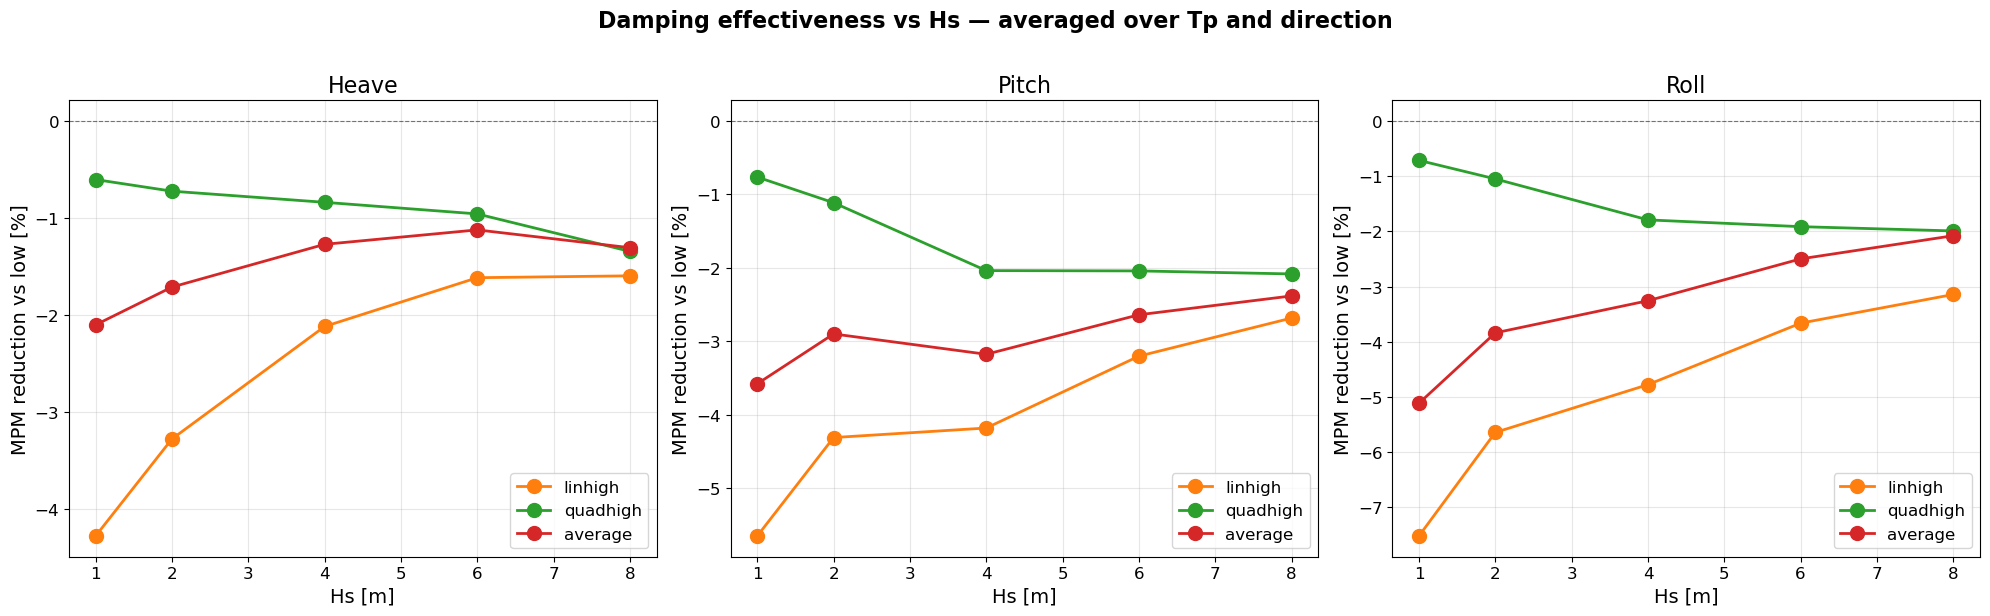

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, dof in zip(axes, DOFS):
    sub_dof = filter_dirs(df, dof)
    dcol = damping_col(dof['key'])
    mpm_c = f'MPM {dof["key"]} corr'

    # baseline: mean over Tp and direction per Hs, for the 'low' case
    base = sub_dof[sub_dof[dcol] == 'low'].groupby('Hs')[mpm_c].mean()

    for case in ['linhigh', 'quadhigh', 'average']:
        case_mpm = sub_dof[sub_dof[dcol] == case].groupby('Hs')[mpm_c].mean()
        common = case_mpm.index.intersection(base.index)
        pct = (case_mpm.loc[common] - base.loc[common]) / base.loc[common] * 100
        ax.plot(pct.index, pct.values, 'o-',
                label=case, color=DAMPING_COLORS[case], linewidth=2, markersize=10)

    ax.axhline(0, color='black', lw=0.8, ls='--', alpha=0.5)
    ax.set_title(f'{dof["name"]}', fontsize=TITLE_SIZE)
    ax.set_xlabel('Hs [m]', fontsize=LABEL_SIZE)
    ax.set_ylabel('MPM reduction vs low [%]', fontsize=LABEL_SIZE)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=TICK_SIZE)

fig.suptitle('Damping effectiveness vs Hs — averaged over Tp and direction',
             y=1.02, fontweight='bold')
fig.tight_layout()
plt.show()

## 5. Effect of damping vs Tp — does quadratic grow with Tp?

Same idea, but now the % reduction is averaged over Hs and direction, plotted vs Tp.

If quadratic damping becomes more effective at higher Tp, the green line should drop faster as Tp increases.

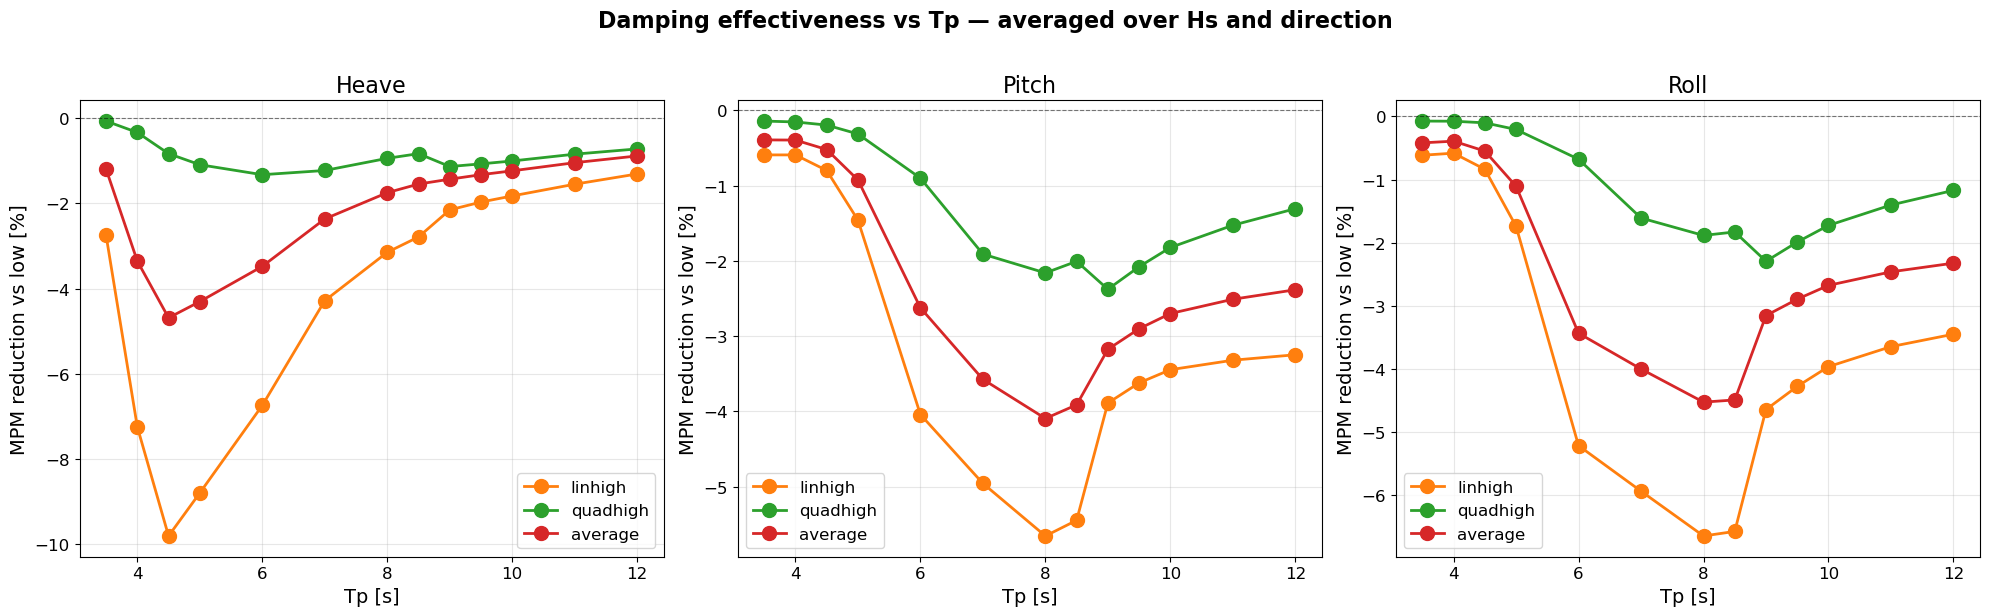

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, dof in zip(axes, DOFS):
    sub_dof = filter_dirs(df, dof)
    dcol = damping_col(dof['key'])
    mpm_c = f'MPM {dof["key"]} corr'

    base = sub_dof[sub_dof[dcol] == 'low'].groupby('Tp')[mpm_c].mean()

    for case in ['linhigh', 'quadhigh', 'average']:
        case_mpm = sub_dof[sub_dof[dcol] == case].groupby('Tp')[mpm_c].mean()
        common = case_mpm.index.intersection(base.index)
        pct = (case_mpm.loc[common] - base.loc[common]) / base.loc[common] * 100
        ax.plot(pct.index, pct.values, 'o-',
                label=case, color=DAMPING_COLORS[case], linewidth=2, markersize=10)

    ax.axhline(0, color='black', lw=0.8, ls='--', alpha=0.5)
    ax.set_title(f'{dof["name"]}', fontsize=TITLE_SIZE)
    ax.set_xlabel('Tp [s]', fontsize=LABEL_SIZE)
    ax.set_ylabel('MPM reduction vs low [%]', fontsize=LABEL_SIZE)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=TICK_SIZE)

fig.suptitle('Damping effectiveness vs Tp — averaged over Hs and direction',
             y=1.02, fontweight='bold')
fig.tight_layout()
plt.show()

## 6. Direct quadratic-vs-linear comparison

Two panels per DOF: % MPM reduction vs `low`, plotted against Hs (left) and Tp (right). Only `linhigh` and `quadhigh` are shown, so the crossover is visible. The claim holds when `quadhigh` (green) drops below `linhigh` (orange) as Hs or Tp grows.

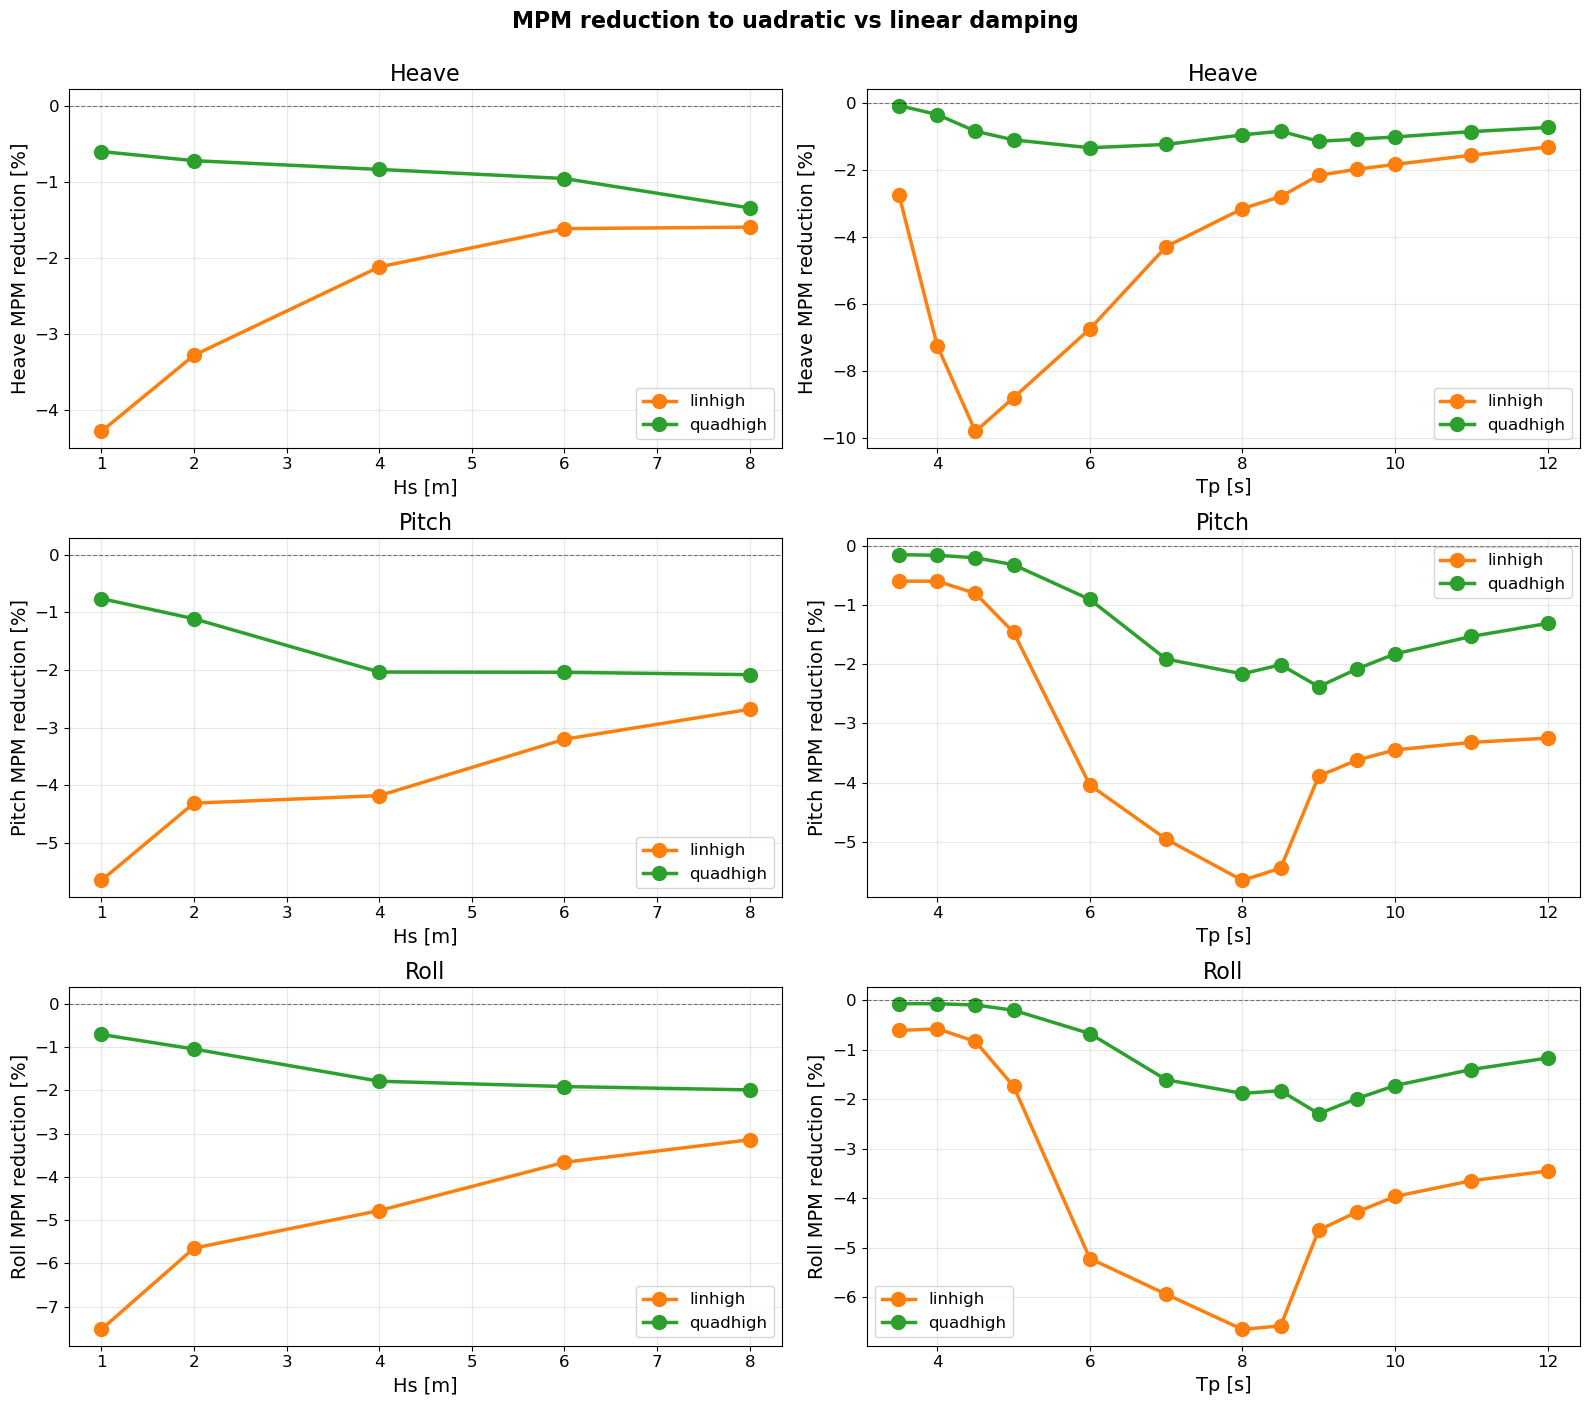

In [9]:
fig, axes = plt.subplots(3, 2, figsize=(16, 14))

for r, dof in enumerate(DOFS):
    sub_dof = filter_dirs(df, dof)
    dcol = damping_col(dof['key'])
    mpm_c = f'MPM {dof["key"]} corr'

    # vs Hs
    ax = axes[r, 0]
    base = sub_dof[sub_dof[dcol] == 'low'].groupby('Hs')[mpm_c].mean()
    for case in ['linhigh', 'quadhigh']:
        case_mpm = sub_dof[sub_dof[dcol] == case].groupby('Hs')[mpm_c].mean()
        pct = (case_mpm - base) / base * 100
        ax.plot(pct.index, pct.values, 'o-',
                label=case, color=DAMPING_COLORS[case],
                linewidth=2.5, markersize=10)
    ax.axhline(0, color='black', lw=0.8, ls='--', alpha=0.5)
    ax.set_xlabel('Hs [m]', fontsize=LABEL_SIZE)
    ax.set_ylabel(f'{dof["name"]} MPM reduction [%]', fontsize=LABEL_SIZE)
    ax.set_title(f'{dof["name"]}', fontsize=TITLE_SIZE)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=TICK_SIZE)

    # vs Tp
    ax = axes[r, 1]
    base = sub_dof[sub_dof[dcol] == 'low'].groupby('Tp')[mpm_c].mean()
    for case in ['linhigh', 'quadhigh']:
        case_mpm = sub_dof[sub_dof[dcol] == case].groupby('Tp')[mpm_c].mean()
        pct = (case_mpm - base) / base * 100
        ax.plot(pct.index, pct.values, 'o-',
                label=case, color=DAMPING_COLORS[case],
                linewidth=2.5, markersize=10)
    ax.axhline(0, color='black', lw=0.8, ls='--', alpha=0.5)
    ax.set_xlabel('Tp [s]', fontsize=LABEL_SIZE)
    ax.set_ylabel(f'{dof["name"]} MPM reduction [%]', fontsize=LABEL_SIZE)
    ax.set_title(f'{dof["name"]}', fontsize=TITLE_SIZE)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=TICK_SIZE)

fig.suptitle('MPM reduction to uadratic vs linear damping',
             y=1.00, fontweight='bold')
fig.tight_layout()
plt.show()

In [10]:
# fig, axes = plt.subplots(3, 1, figsize=(10, 14))

# for r, dof in enumerate(DOFS):
#     sub_dof = filter_dirs(df, dof)
#     dcol = damping_col(dof['key'])
#     mpm_c = f'MPM {dof["key"]} corr'

#     # vs Hs
#     ax = axes[r]
#     base = sub_dof[sub_dof[dcol] == 'low'].groupby('Hs')[mpm_c].mean()
#     for case in ['linhigh', 'quadhigh', 'average']:
#         case_mpm = sub_dof[sub_dof[dcol] == case].groupby('Hs')[mpm_c].mean()
#         pct = (case_mpm - base) / base * 100
#         ax.plot(pct.index, pct.values, 'o-',
#                 label=case, color=DAMPING_COLORS[case],
#                 linewidth=2.5, markersize=10)
#     ax.axhline(0, color='black', lw=0.8, ls='--', alpha=0.5)
#     ax.set_xlabel('Hs [m]', fontsize=LABEL_SIZE)
#     ax.set_ylabel(f'{dof["name"]} MPM reduction [%]', fontsize=LABEL_SIZE)
#     ax.set_title(f'{dof["name"]}', fontsize=TITLE_SIZE)
#     ax.grid(True, alpha=0.3)
#     ax.legend(fontsize=TICK_SIZE)

# #     # vs Tp
# #     ax = axes[r, 1]
# #     base = sub_dof[sub_dof[dcol] == 'low'].groupby('Tp')[mpm_c].mean()
# #     for case in ['linhigh', 'quadhigh']:
# #         case_mpm = sub_dof[sub_dof[dcol] == case].groupby('Tp')[mpm_c].mean()
# #         pct = (case_mpm - base) / base * 100
# #         ax.plot(pct.index, pct.values, 'o-',
# #                 label=case, color=DAMPING_COLORS[case],
# #                 linewidth=2.5, markersize=10)
# #     ax.axhline(0, color='black', lw=0.8, ls='--', alpha=0.5)
# #     ax.set_xlabel('Tp [s]', fontsize=LABEL_SIZE)
# #     ax.set_ylabel(f'{dof["name"]} MPM reduction [%]', fontsize=LABEL_SIZE)
# #     ax.set_title(f'{dof["name"]}', fontsize=TITLE_SIZE)
# #     ax.grid(True, alpha=0.3)
# #     ax.legend(fontsize=TICK_SIZE)

# fig.suptitle('MPM reduction vs Hs',
#              y=1.00, fontweight='bold')
# fig.tight_layout()
# plt.show()

In [11]:
# TP_VALUES = sorted(df['Tp'].unique())

# for tp in TP_VALUES:
#     sub_tp = df[df['Tp'] == tp]
#     fig, axes = plt.subplots(3, 1, figsize=(10, 14))

#     for r, dof in enumerate(DOFS):
#         sub_dof = filter_dirs(sub_tp, dof)
#         dcol = damping_col(dof['key'])
#         mpm_c = f'MPM {dof["key"]} corr'

#         ax = axes[r]
#         base = sub_dof[sub_dof[dcol] == 'low'].groupby('Hs')[mpm_c].mean()
#         for case in ['linhigh', 'quadhigh', 'average']:
#             case_mpm = sub_dof[sub_dof[dcol] == case].groupby('Hs')[mpm_c].mean()
#             common = case_mpm.index.intersection(base.index)
#             if len(common) == 0:
#                 continue
#             pct = (case_mpm.loc[common] - base.loc[common]) / base.loc[common] * 100
#             ax.plot(common, pct.values, 'o-',
#                     label=case, color=DAMPING_COLORS[case],
#                     linewidth=2.5, markersize=10)
#         ax.axhline(0, color='black', lw=0.8, ls='--', alpha=0.5)
#         ax.set_xlabel('Hs [m]', fontsize=LABEL_SIZE)
#         ax.set_ylabel(f'{dof["name"]} MPM reduction [%]', fontsize=LABEL_SIZE)
#         ax.set_title(f'{dof["name"]}', fontsize=TITLE_SIZE)
#         ax.tick_params(axis='both', labelsize=TICK_SIZE)
#         ax.grid(True, alpha=0.3)
#         ax.legend(fontsize=TICK_SIZE)

#     fig.suptitle(f'MPM reduction vs Hs — Tp = {tp} s',
#                  y=1.00, fontsize=TITLE_SIZE + 2, fontweight='bold')
#     fig.tight_layout()

# plt.show()

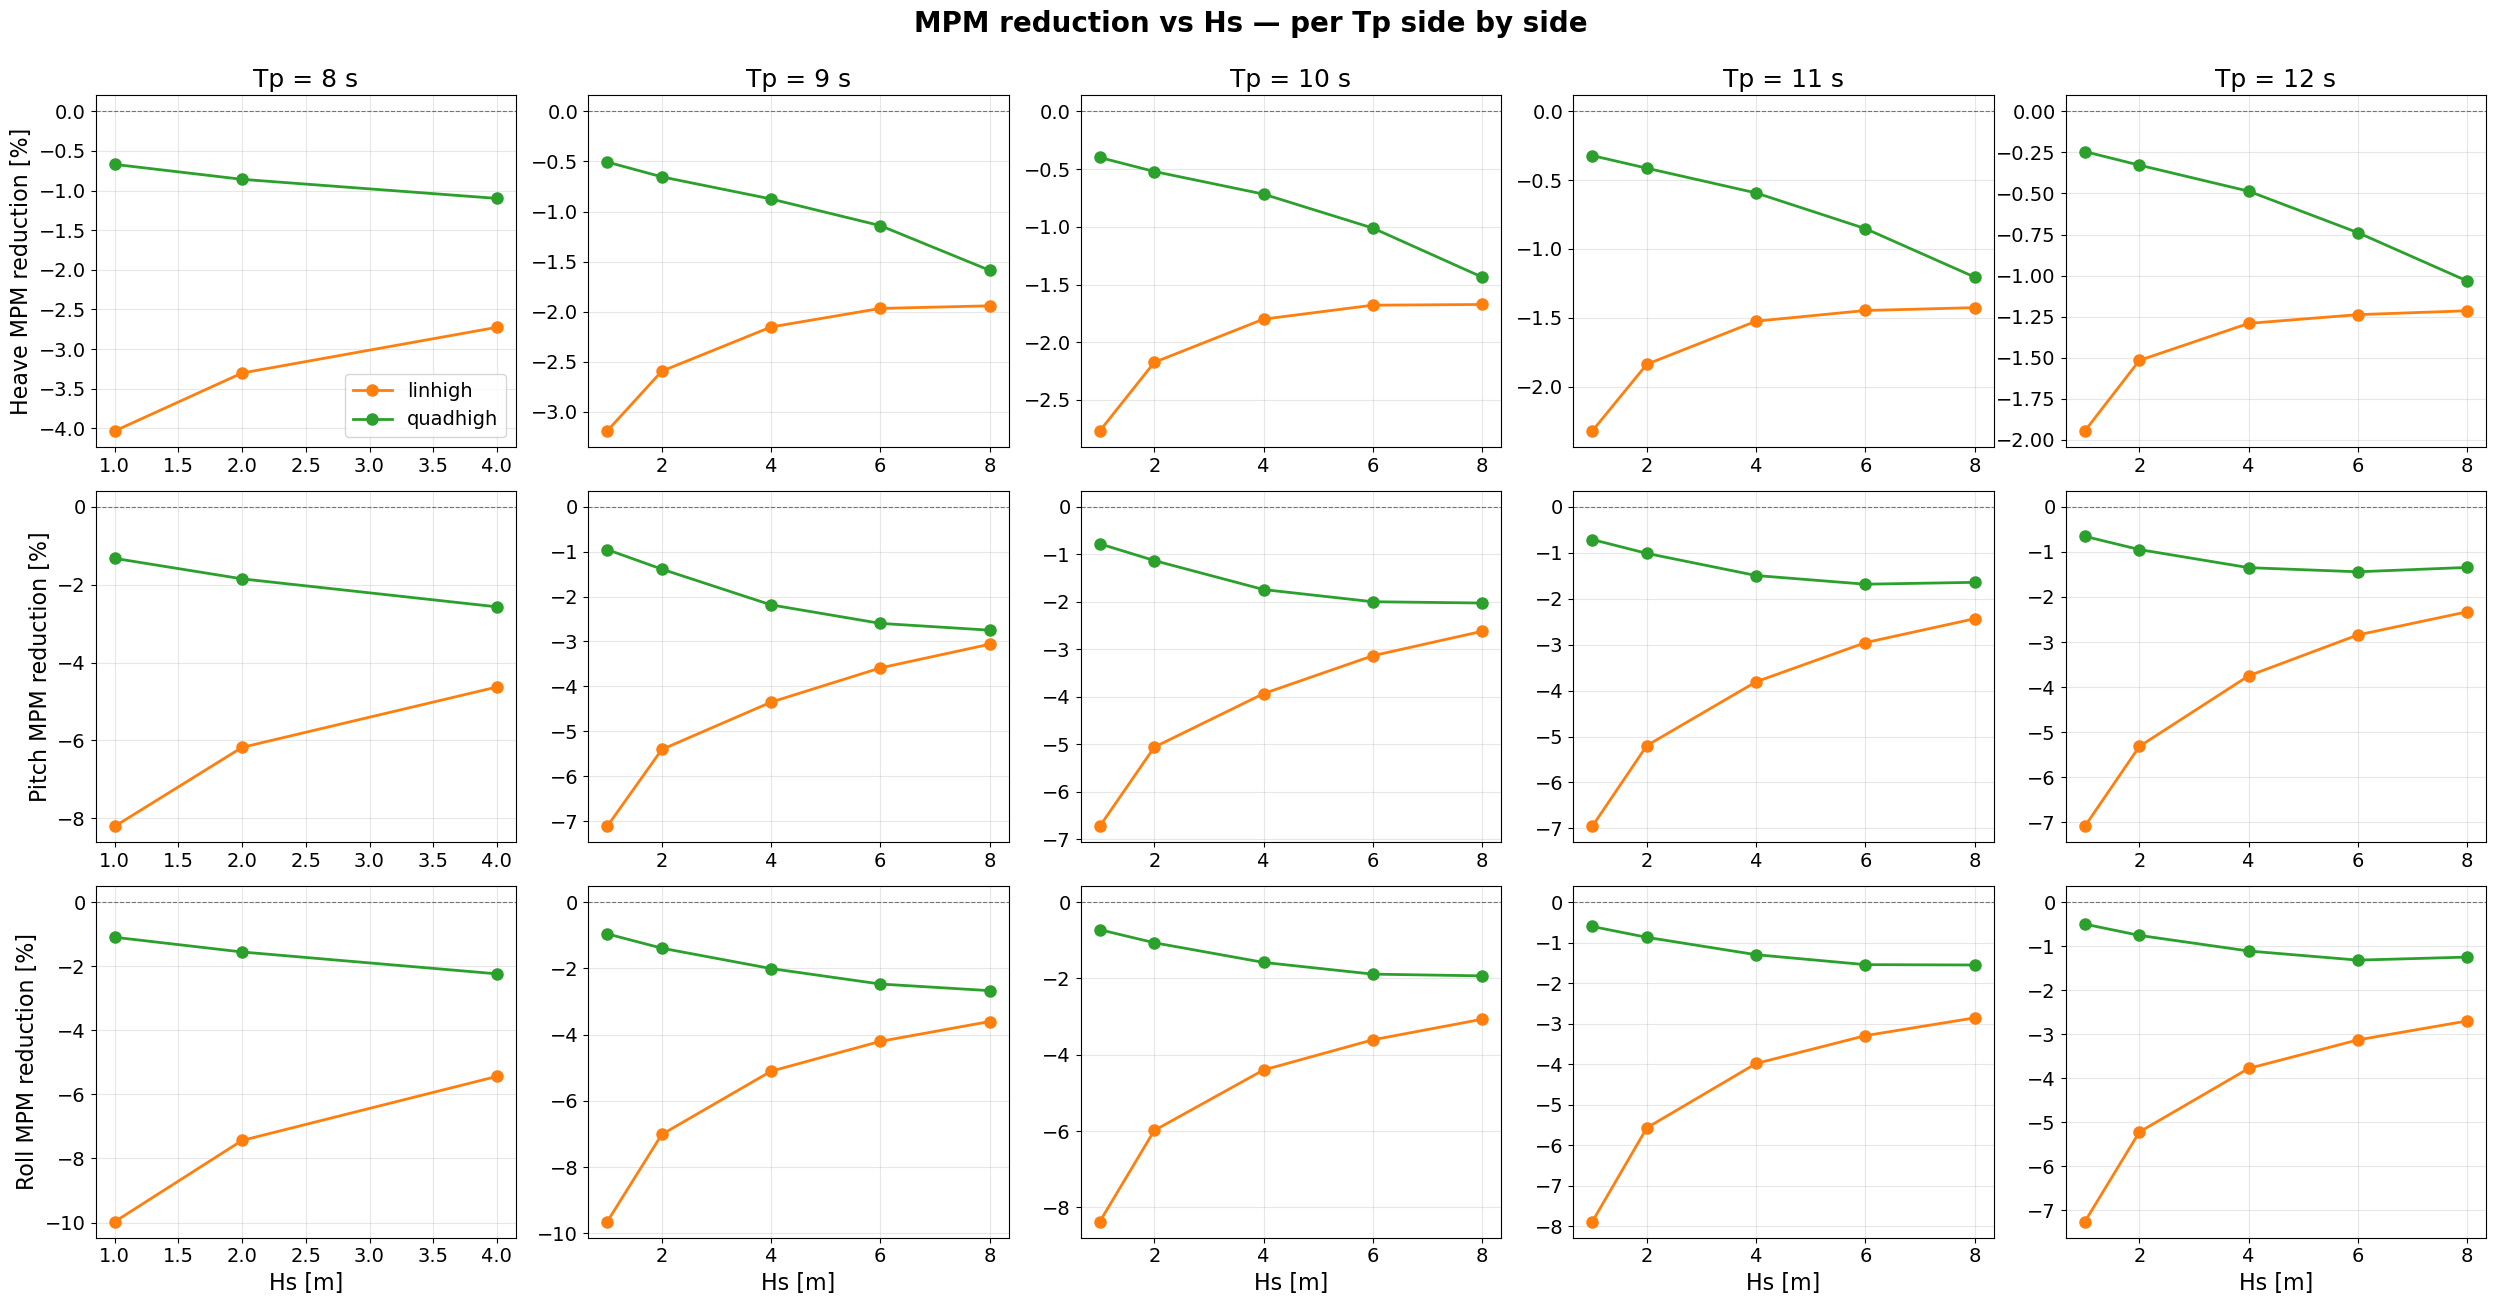

In [45]:
# Combined overview: MPM reduction vs Hs for a selection of Tp values side by side
TP_SELECTION = [8, 9, 10,11,12]

fig, axes = plt.subplots(3, len(TP_SELECTION), figsize=(5*len(TP_SELECTION), 13),
                         squeeze=False)

for c, tp in enumerate(TP_SELECTION):
    sub_tp = df[df['Tp'] == tp]
    for r, dof in enumerate(DOFS):
        ax = axes[r, c]
        sub_dof = filter_dirs(sub_tp, dof)
        dcol = damping_col(dof['key'])
        mpm_c = f'MPM {dof["key"]} corr'

        base = sub_dof[sub_dof[dcol] == 'low'].groupby('Hs')[mpm_c].mean()
        for case in ['linhigh', 'quadhigh']:
            case_mpm = sub_dof[sub_dof[dcol] == case].groupby('Hs')[mpm_c].mean()
            common = case_mpm.index.intersection(base.index)
            if len(common) == 0:
                continue
            pct = (case_mpm.loc[common] - base.loc[common]) / base.loc[common] * 100
            ax.plot(common, pct.values, 'o-',
                    label=case, color=DAMPING_COLORS[case],
                    linewidth=2, markersize=8)

        ax.axhline(0, color='black', lw=0.8, ls='--', alpha=0.5)
        ax.grid(True, alpha=0.3)
        ax.tick_params(axis='both', labelsize=TICK_SIZE)
        if r == 0:
            ax.set_title(f'Tp = {tp} s', fontsize=TITLE_SIZE)
        if r == 0 and c == 0:
            ax.legend(fontsize=TICK_SIZE)
        if r == 2:
            ax.set_xlabel('Hs [m]', fontsize=LABEL_SIZE)
        if c == 0:
            ax.set_ylabel(f'{dof["name"]} MPM reduction [%]', fontsize=LABEL_SIZE)

fig.suptitle('MPM reduction vs Hs — per Tp side by side',
             y=1.00, fontsize=TITLE_SIZE + 2, fontweight='bold')
fig.tight_layout()
plt.show()

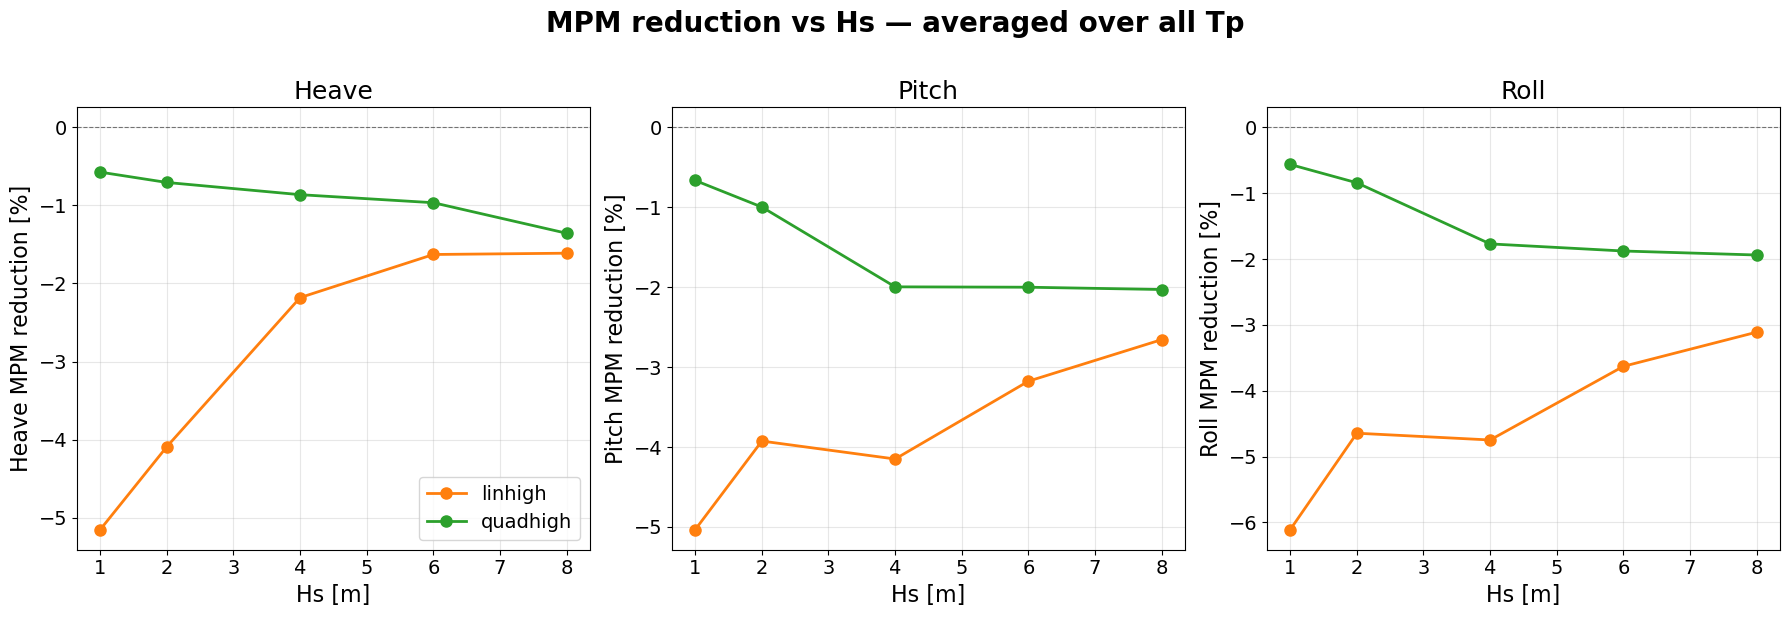

In [46]:
# Combined overview: MPM reduction vs Hs, averaged over all Tp values
fig, axes = plt.subplots(1, 3, figsize=(18, 6), squeeze=False)

for r, dof in enumerate(DOFS):
    ax = axes[0, r]
    sub_dof = filter_dirs(df, dof)
    dcol = damping_col(dof['key'])
    mpm_c = f'MPM {dof["key"]} corr'

    # mean MPM per (case, Hs, Tp)
    grouped = sub_dof.groupby([dcol, 'Hs', 'Tp'])[mpm_c].mean()
    base = grouped.xs('low', level=dcol)   # indexed by (Hs, Tp)

    for case in ['linhigh', 'quadhigh']:
        if case not in grouped.index.get_level_values(dcol):
            continue
        case_mpm = grouped.xs(case, level=dcol)   # indexed by (Hs, Tp)
        common = case_mpm.index.intersection(base.index)
        if len(common) == 0:
            continue
        # percentage per (Hs, Tp), then average over Tp per Hs
        pct = (case_mpm.loc[common] - base.loc[common]) / base.loc[common] * 100
        pct_mean = pct.groupby('Hs').mean().sort_index()
        ax.plot(pct_mean.index, pct_mean.values, 'o-',
                label=case, color=DAMPING_COLORS[case],
                linewidth=2, markersize=8)

    ax.axhline(0, color='black', lw=0.8, ls='--', alpha=0.5)
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='both', labelsize=TICK_SIZE)
    ax.set_title(dof['name'], fontsize=TITLE_SIZE)
    ax.set_xlabel('Hs [m]', fontsize=LABEL_SIZE)
    ax.set_ylabel(f'{dof["name"]} MPM reduction [%]', fontsize=LABEL_SIZE)
    if r == 0:
        ax.legend(fontsize=TICK_SIZE)

fig.suptitle('MPM reduction vs Hs — averaged over all Tp',
             y=1.02, fontsize=TITLE_SIZE + 2, fontweight='bold')
fig.tight_layout()
plt.show()

[Heave] warning: common Tp window [9.0, 12.0] is much narrower than full range [3.5, 12.0] — comparison trims a lot.
[Pitch] warning: common Tp window [9.0, 12.0] is much narrower than full range [3.5, 12.0] — comparison trims a lot.
[Roll] warning: common Tp window [9.0, 12.0] is much narrower than full range [3.5, 12.0] — comparison trims a lot.


C:\Users\verav\AppData\Local\Temp\ipykernel_34096\3682236879.py:31: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trapz(val_w, tp_w) / (hi - lo)
C:\Users\verav\AppData\Local\Temp\ipykernel_34096\3682236879.py:31: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trapz(val_w, tp_w) / (hi - lo)
C:\Users\verav\AppData\Local\Temp\ipykernel_34096\3682236879.py:31: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trapz(val_w, tp_w) / (hi - lo)


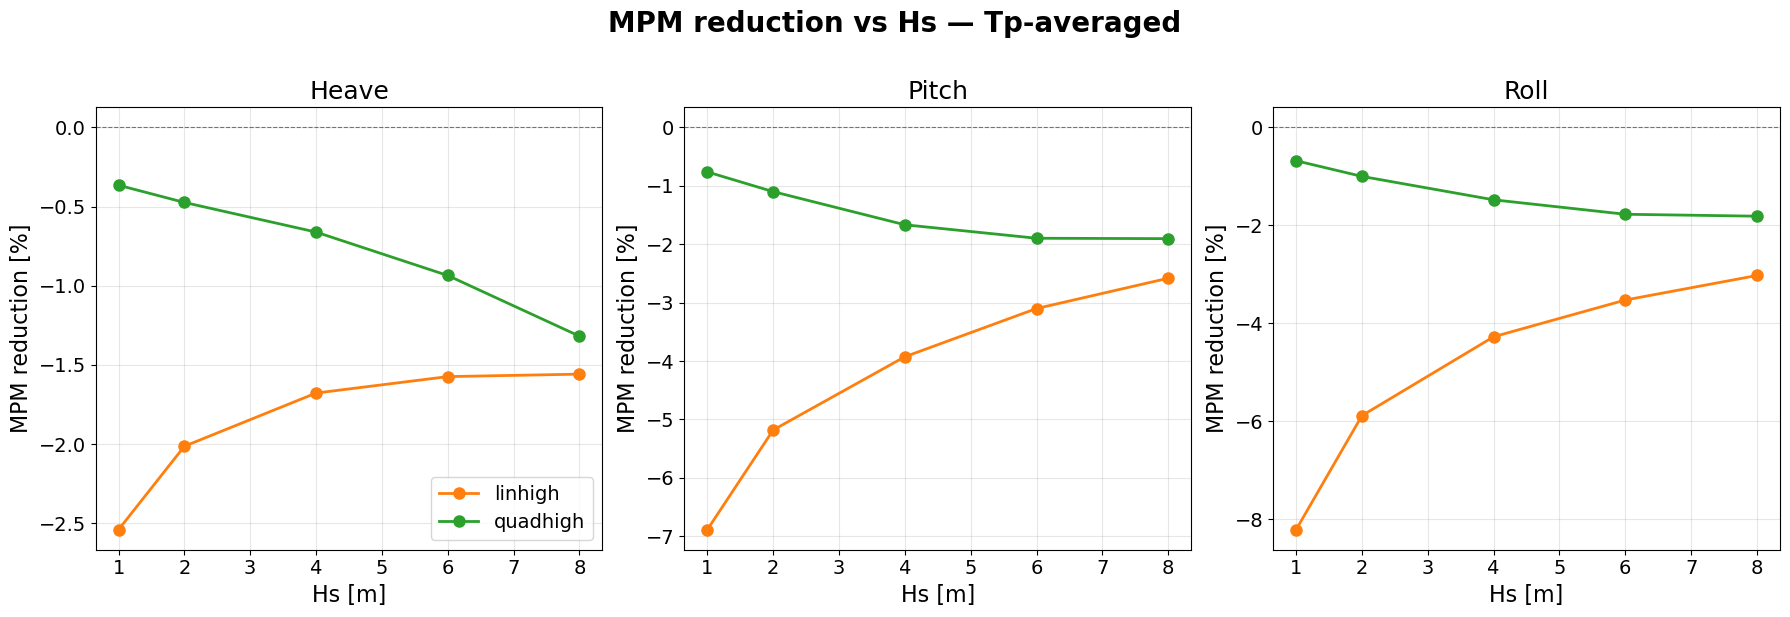

In [50]:
import numpy as np

# Combined overview: MPM reduction vs Hs, Tp-averaged via trapezoidal integration.
# Tp grid differs per case, so each subplot integrates over the COMMON Tp range
# shared by all curves, ensuring Hs points are compared over the same interval.
fig, axes = plt.subplots(1, 3, figsize=(18, 6), squeeze=False)

def trap_mean(series, lo, hi):
    """Trapezoidal average of `series` (indexed by Tp) over [lo, hi].
    Endpoints are linearly interpolated so every Hs uses the exact same range."""
    s = series.sort_index()
    tp = s.index.values.astype(float)
    val = s.values.astype(float)

    # restrict to the common window, interpolating clean endpoints at lo and hi
    inside = (tp >= lo) & (tp <= hi)
    tp_w = tp[inside]
    val_w = val[inside]
    if lo < tp_w[0]:                       # shouldn't happen if lo is the shared min
        val_w = np.insert(val_w, 0, np.interp(lo, tp, val)); tp_w = np.insert(tp_w, 0, lo)
    if hi > tp_w[-1]:
        val_w = np.append(val_w, np.interp(hi, tp, val)); tp_w = np.append(tp_w, hi)

    if tp_w[0] > lo:
        val_w = np.insert(val_w, 0, np.interp(lo, tp, val)); tp_w = np.insert(tp_w, 0, lo)
    if tp_w[-1] < hi:
        val_w = np.append(val_w, np.interp(hi, tp, val)); tp_w = np.append(tp_w, hi)

    if hi == lo:
        return np.interp(lo, tp, val)
    return np.trapz(val_w, tp_w) / (hi - lo)

for r, dof in enumerate(DOFS):
    ax = axes[0, r]
    sub_dof = filter_dirs(df, dof)
    dcol = damping_col(dof['key'])
    mpm_c = f'MPM {dof["key"]} corr'

    grouped = sub_dof.groupby([dcol, 'Hs', 'Tp'])[mpm_c].mean()
    base = grouped.xs('low', level=dcol)

    # collect the per-Hs pct series first so we can find the shared Tp window
    pct_by_case = {}
    for case in ['linhigh', 'quadhigh']:
        if case not in grouped.index.get_level_values(dcol):
            continue
        case_mpm = grouped.xs(case, level=dcol)
        common = case_mpm.index.intersection(base.index)
        if len(common) == 0:
            continue
        pct = (case_mpm.loc[common] - base.loc[common]) / base.loc[common] * 100
        pct_by_case[case] = {hs: g.droplevel('Hs').sort_index()
                             for hs, g in pct.groupby('Hs')}

    # common Tp window = overlap across every (case, Hs) curve in this subplot
    all_series = [s for case in pct_by_case for s in pct_by_case[case].values()]
    if not all_series:
        continue
    lo = max(s.index.min() for s in all_series)
    hi = min(s.index.max() for s in all_series)
    full_lo = min(s.index.min() for s in all_series)
    full_hi = max(s.index.max() for s in all_series)
    if (hi - lo) < 0.5 * (full_hi - full_lo):
        print(f"[{dof['name']}] warning: common Tp window [{lo}, {hi}] is much "
              f"narrower than full range [{full_lo}, {full_hi}] — comparison trims a lot.")

    for case, per_hs in pct_by_case.items():
        hs_vals, means = [], []
        for hs in sorted(per_hs):
            s = per_hs[hs]
            if s.index.min() > lo or s.index.max() < hi:
                continue                       # curve doesn't cover the window
            hs_vals.append(hs)
            means.append(trap_mean(s, lo, hi))
        if not hs_vals:
            continue
        ax.plot(hs_vals, means, 'o-', label=case,
                color=DAMPING_COLORS[case], linewidth=2, markersize=8)

    ax.axhline(0, color='black', lw=0.8, ls='--', alpha=0.5)
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='both', labelsize=TICK_SIZE)
    ax.set_title(f'{dof["name"]}', fontsize=TITLE_SIZE)
    ax.set_xlabel('Hs [m]', fontsize=LABEL_SIZE)
    ax.set_ylabel(f'MPM reduction [%]', fontsize=LABEL_SIZE)
    if r == 0:
        ax.legend(fontsize=TICK_SIZE)

fig.suptitle('MPM reduction vs Hs — Tp-averaged',
             y=1.02, fontsize=TITLE_SIZE + 2, fontweight='bold')
fig.tight_layout()
plt.show()

## 7. `average` damping vs every alternative

3 DOFs (rows) × 3 alternatives (columns: low, linhigh, quadhigh). For each (Hs, Tp) we compute `(average − other) / other × 100%`.  
A positive value means `average` performs **worse** than the alternative; negative means it does better.  
One line per Hs.

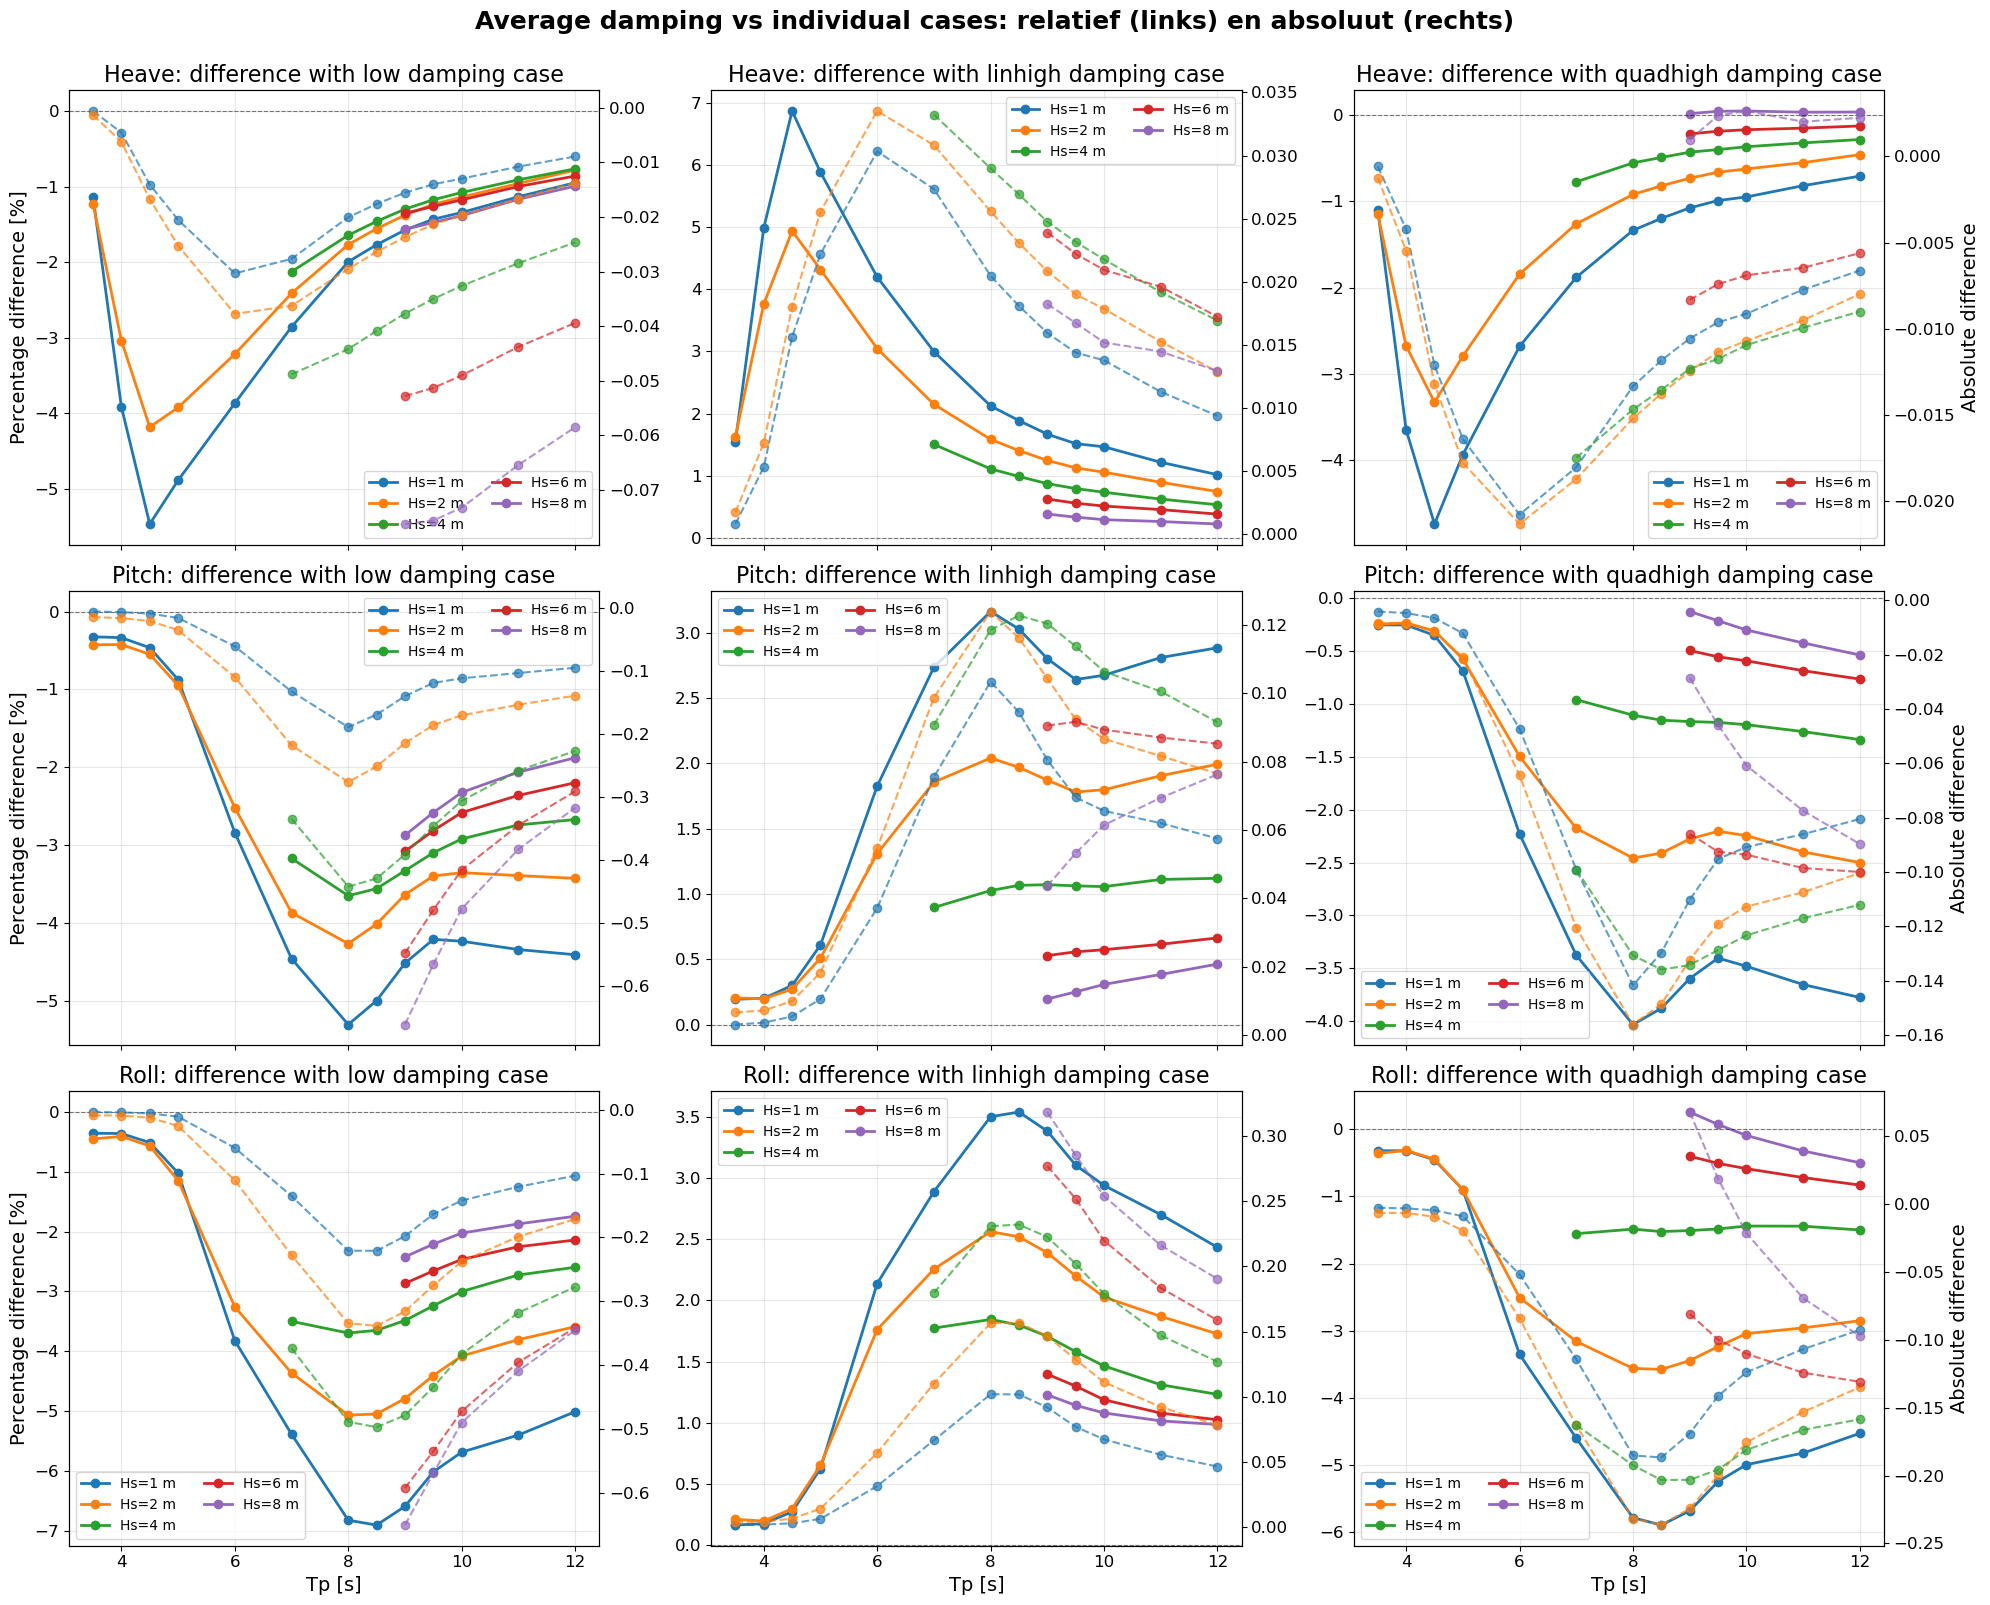

In [22]:
COMPARISONS = ['low', 'linhigh', 'quadhigh']

fig, axes = plt.subplots(3, 3, figsize=(20, 16), sharex=True)

for r, dof in enumerate(DOFS):
    sub_dof = filter_dirs(df, dof)
    dcol = damping_col(dof['key'])
    mpm_c = f'MPM {dof["key"]} corr'

    pivot = sub_dof.groupby([dcol, 'Hs', 'Tp'])[mpm_c].mean().unstack(dcol)
    if 'average' not in pivot.columns:
        continue
    avg = pivot['average']

    for c, other in enumerate(COMPARISONS):
        ax = axes[r, c]              # linker y-as: relatieve afname [%]
        if other not in pivot.columns:
            ax.set_visible(False)
            continue
        ax2 = ax.twinx()            # rechter y-as: absolute afname

        diff_abs = (avg - pivot[other]).rename('diff_abs').reset_index()
        diff_pct = ((avg - pivot[other]) / pivot[other] * 100).rename('diff').reset_index()

        for hs in HS_VALUES:
            s_pct = diff_pct[diff_pct['Hs'] == hs].sort_values('Tp')
            s_abs = diff_abs[diff_abs['Hs'] == hs].sort_values('Tp')
            if s_pct.empty:
                continue
            # relatief op linker-as
            line, = ax.plot(s_pct['Tp'], s_pct['diff'], 'o-', label=f'Hs={hs} m', linewidth=2)
            # absoluut op rechter-as, zelfde kleur
            ax2.plot(s_abs['Tp'], s_abs['diff_abs'], 'o--',
                     color=line.get_color(), linewidth=1.5, markersize=6, alpha=0.7)

        ax.axhline(0, color='black', lw=0.8, ls='--', alpha=0.5)
        ax.set_title(f'{dof["name"]}: difference with {other} damping case', fontsize=TITLE_SIZE)
        ax.tick_params(axis='both', labelsize=TICK_SIZE)
        ax2.tick_params(axis='y', labelsize=TICK_SIZE)
        ax.grid(True, alpha=0.3)
        if r == 2:
            ax.set_xlabel('Tp [s]', fontsize=LABEL_SIZE)
        if c == 0:
            ax.set_ylabel('Percentage difference [%]', fontsize=LABEL_SIZE)
        if c == 2:
            ax2.set_ylabel('Absolute difference', fontsize=LABEL_SIZE)
        ax.legend(fontsize=TICK_SIZE - 2, ncol=2)

fig.suptitle('Average damping vs individual cases: relatief (links) en absoluut (rechts)',
             y=1.00, fontsize=TITLE_SIZE + 2, fontweight='bold')
fig.tight_layout()
plt.show()

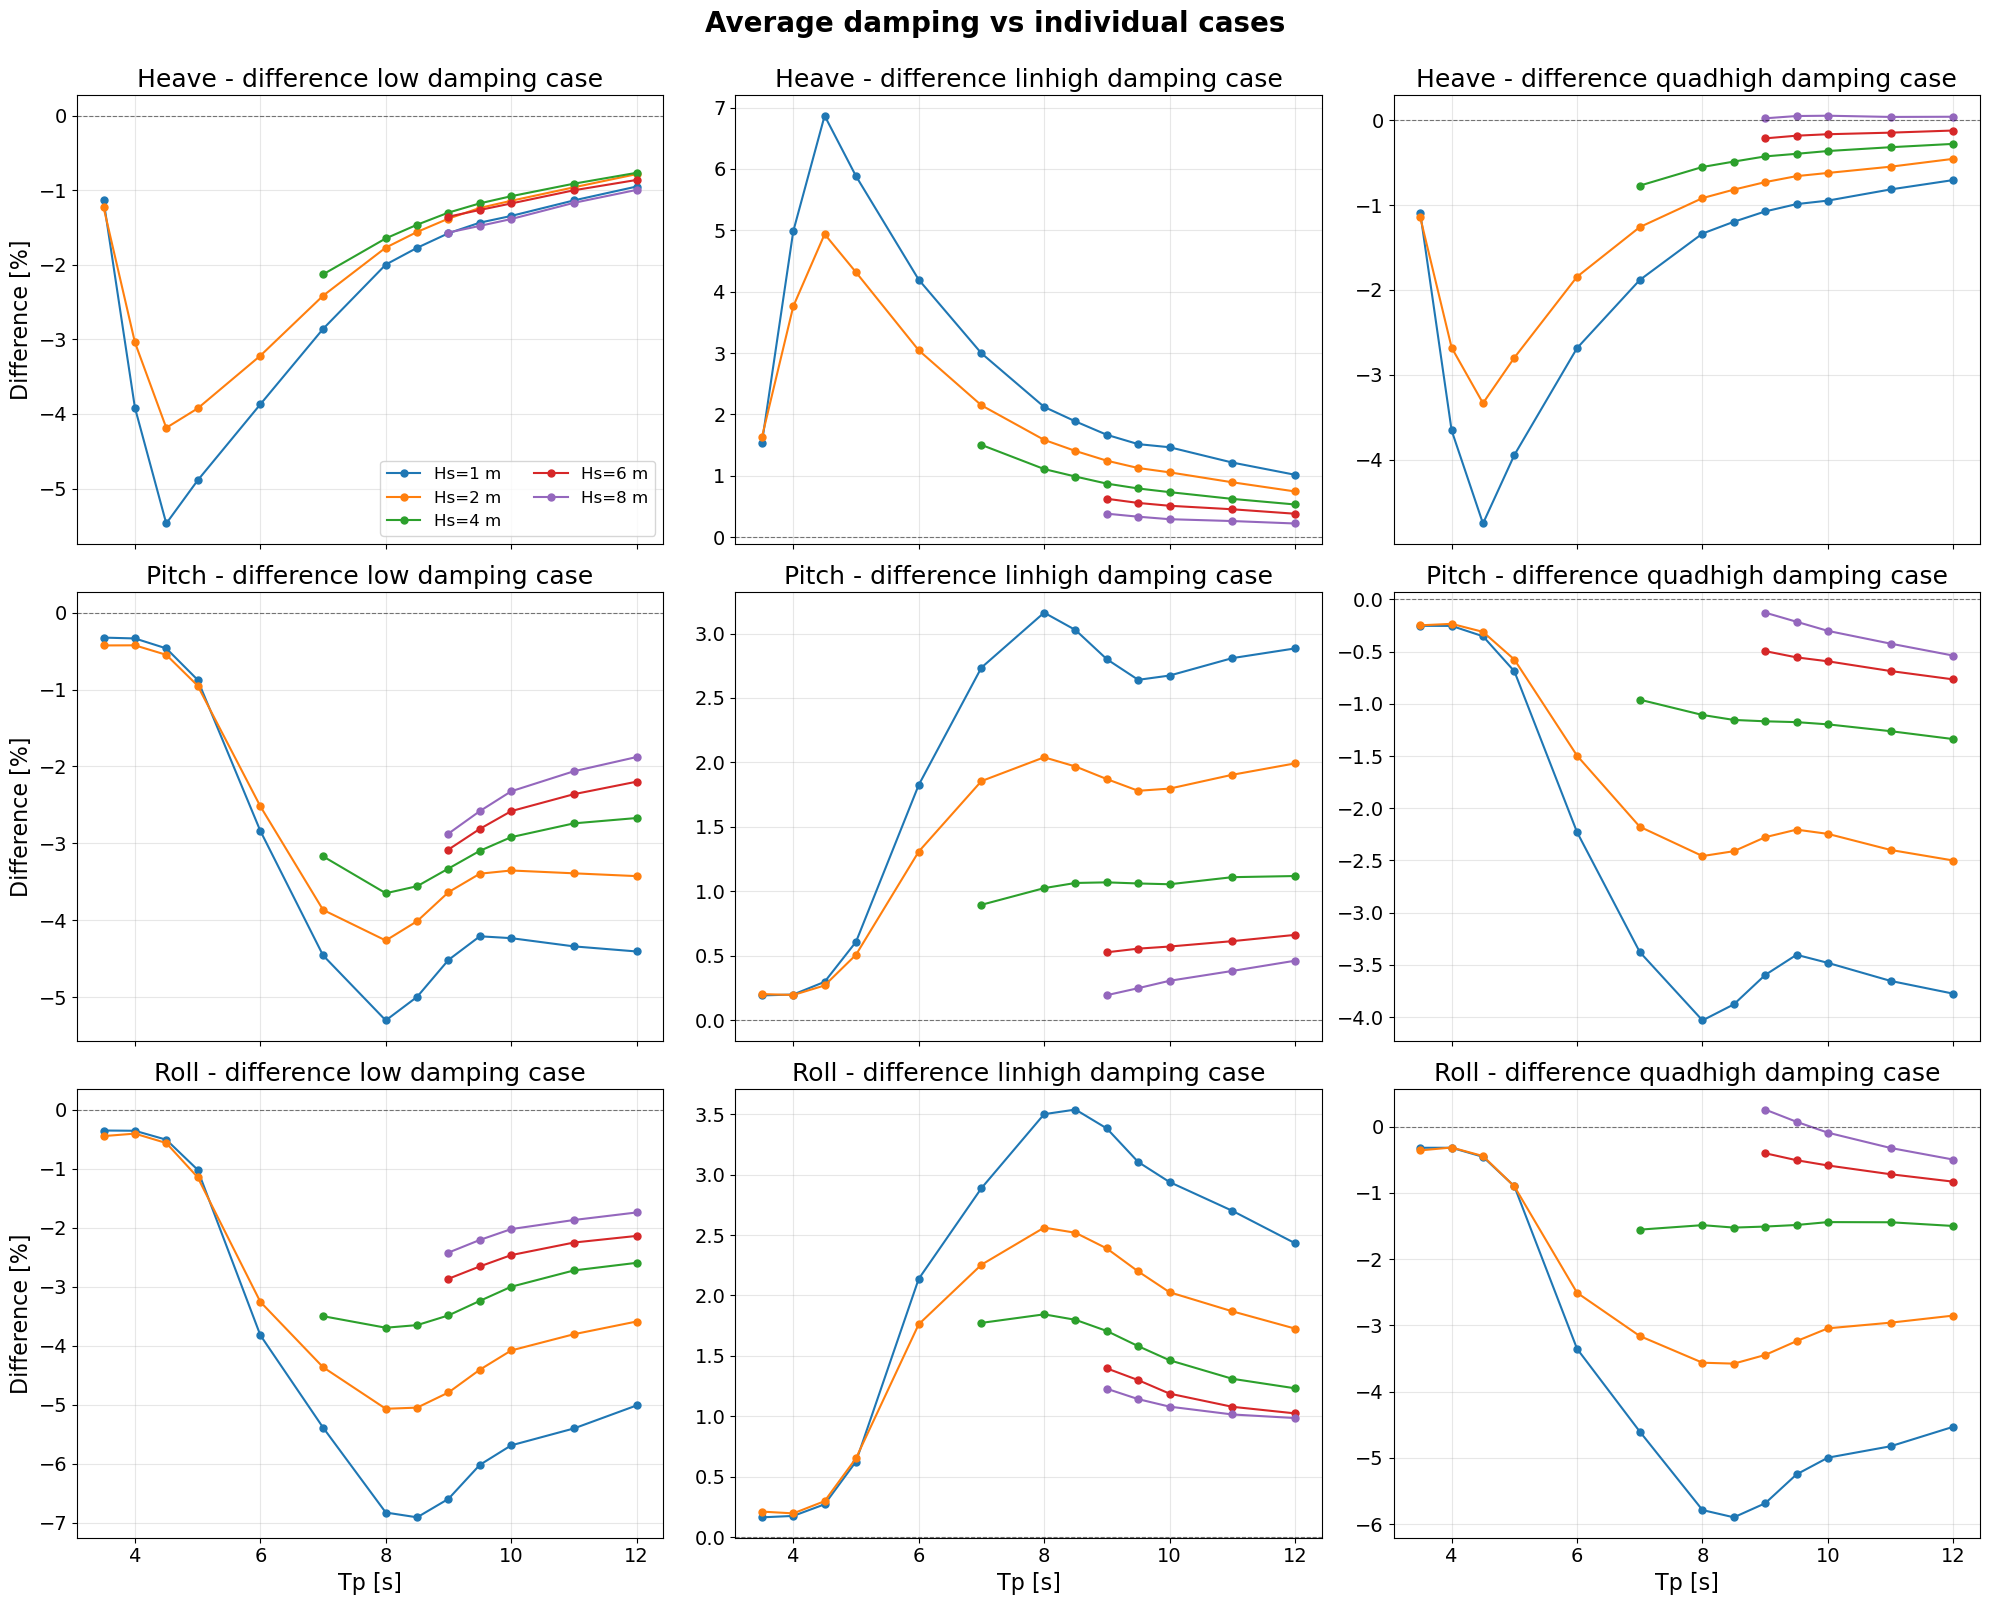

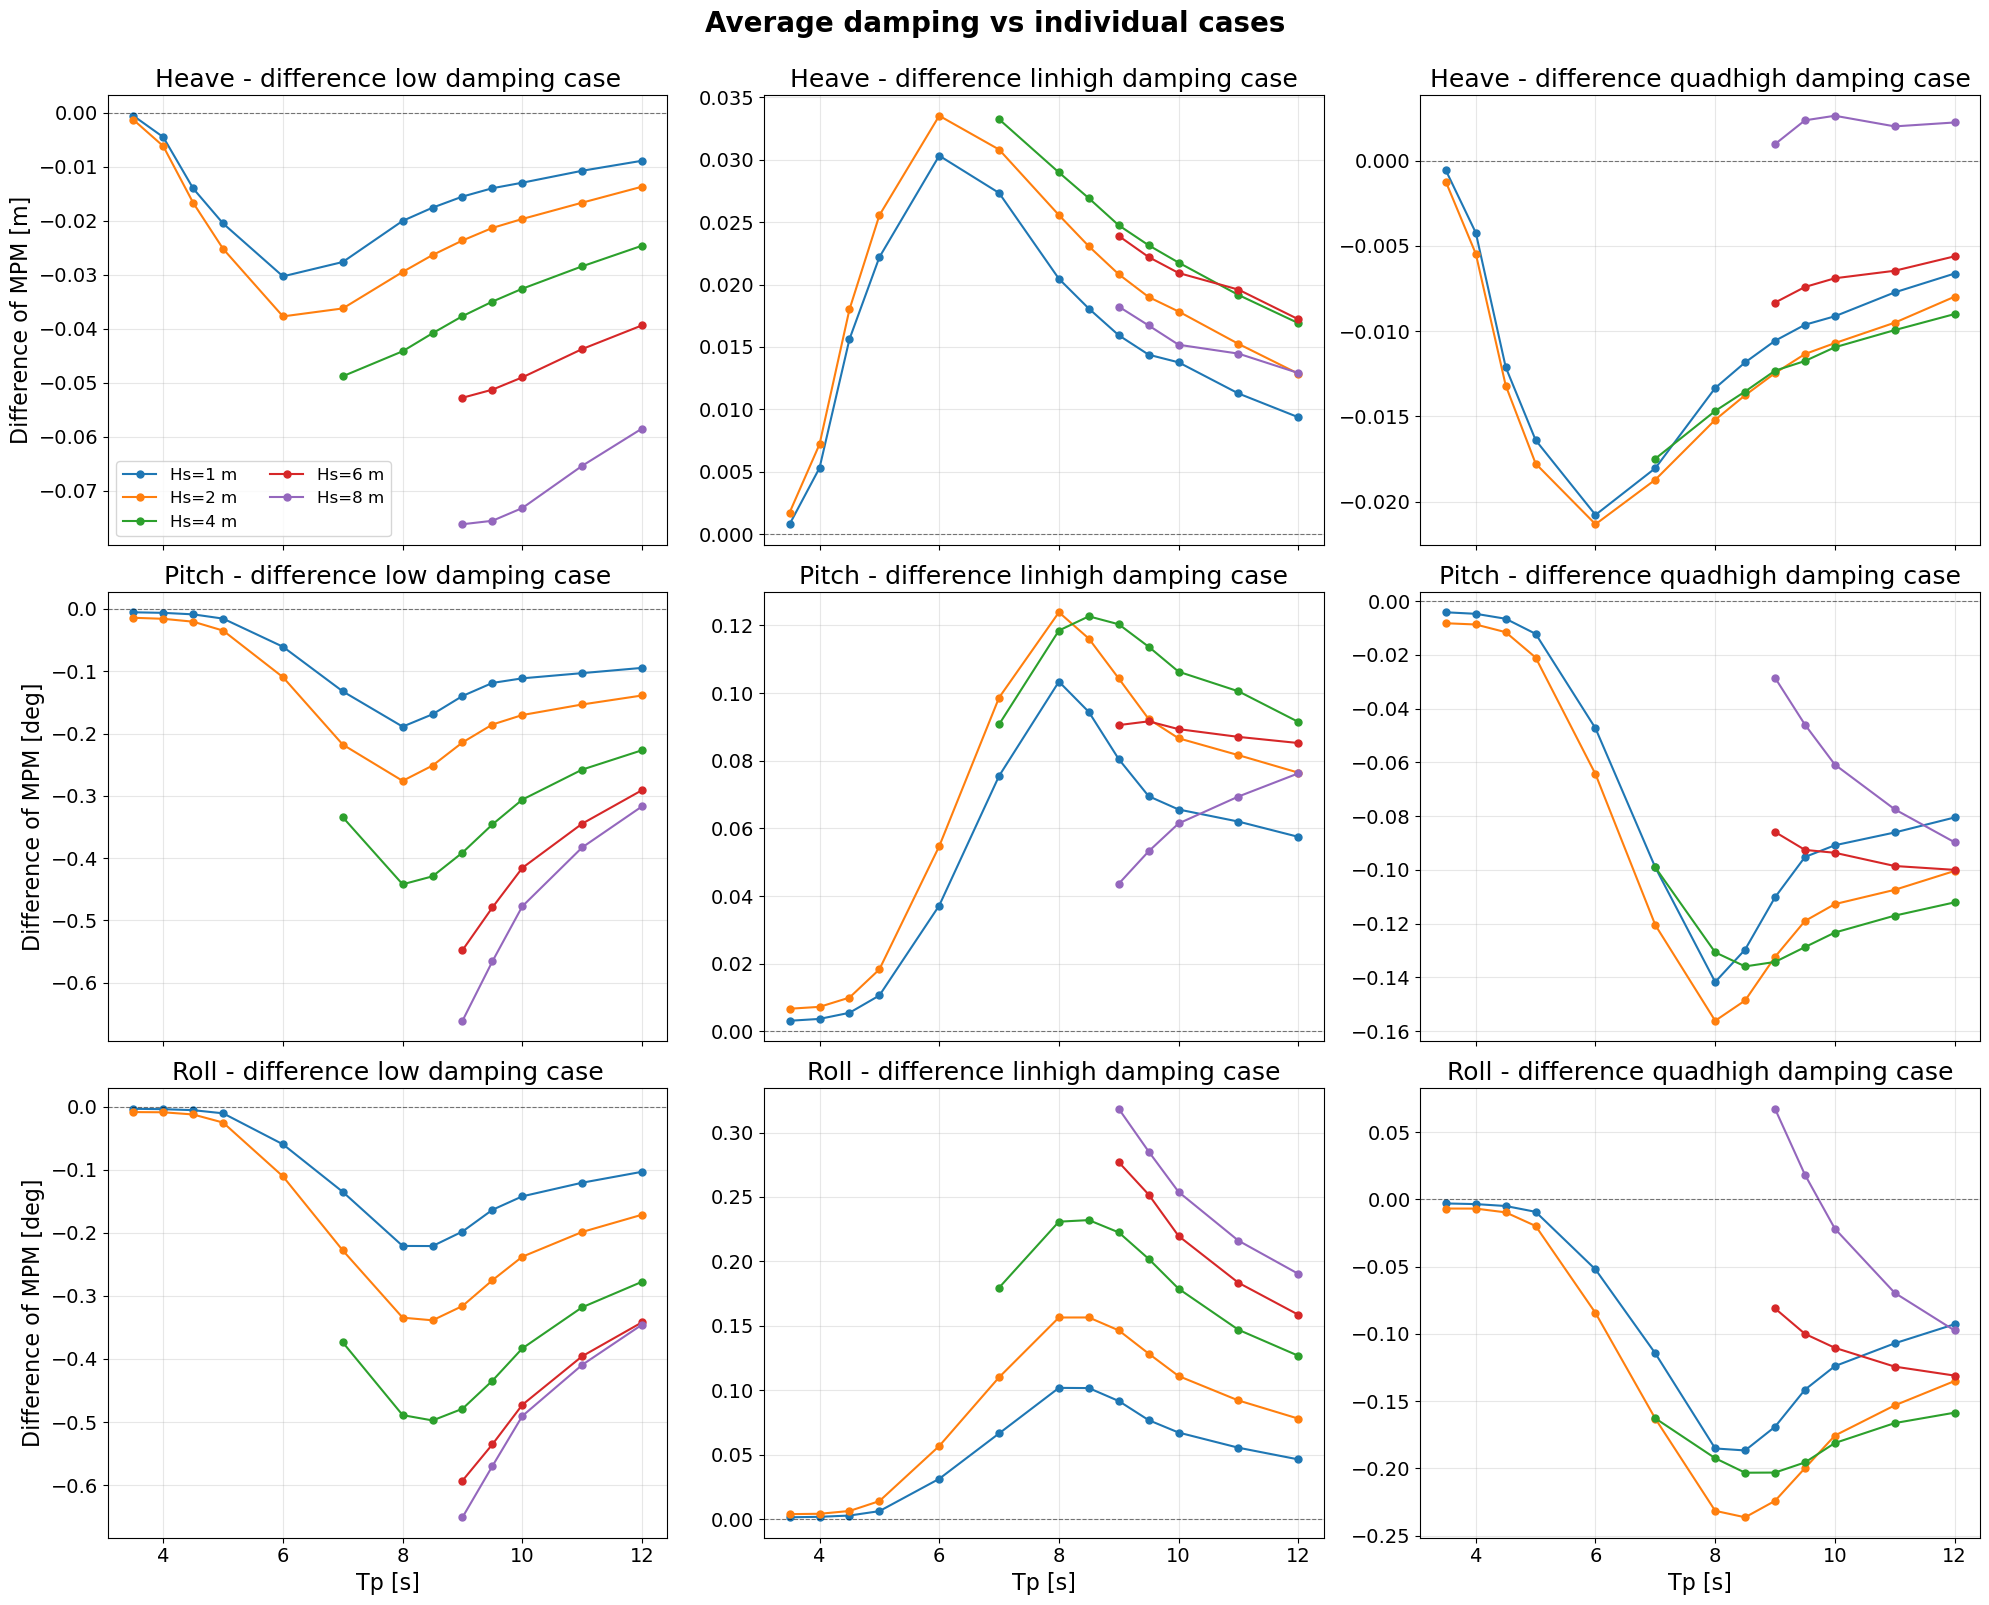

In [43]:
COMPARISONS = ['low', 'linhigh', 'quadhigh']

def plot_grid(df, value='pct'):
    """value='pct' -> relatieve afname [%], value='abs' -> absolute afname."""
    fig, axes = plt.subplots(3, 3, figsize=(20, 16), sharex=True)

    for r, dof in enumerate(DOFS):
        sub_dof = filter_dirs(df, dof)
        dcol = damping_col(dof['key'])
        mpm_c = f'MPM {dof["key"]} corr'

        pivot = sub_dof.groupby([dcol, 'Hs', 'Tp'])[mpm_c].mean().unstack(dcol)
        if 'average' not in pivot.columns:
            continue
        avg = pivot['average']

        for c, other in enumerate(COMPARISONS):
            ax = axes[r, c]
            if other not in pivot.columns:
                ax.set_visible(False)
                continue

            if value == 'pct':
                data = ((avg - pivot[other]) / pivot[other] * 100).rename('val').reset_index()
            else:
                data = (avg - pivot[other]).rename('val').reset_index()

            for hs in HS_VALUES:
                s = data[data['Hs'] == hs].sort_values('Tp')
                if s.empty:
                    continue
                ax.plot(s['Tp'], s['val'], 'o-', label=f'Hs={hs} m',
                        linewidth=1.5, markersize=5)

            ax.axhline(0, color='black', lw=0.8, ls='--', alpha=0.5)
            ax.set_title(f'{dof["name"]} - difference {other} damping case', fontsize=TITLE_SIZE)
            ax.tick_params(axis='both', labelsize=TICK_SIZE)
            ax.grid(True, alpha=0.3)
            if r == 2:
                ax.set_xlabel('Tp [s]', fontsize=LABEL_SIZE)
            if c == 0:
                if r == 0:
                    ylabel = 'Difference [%]' if value == 'pct' else 'Difference of MPM [m]'
                else:
                    ylabel = 'Difference [%]' if value == 'pct' else 'Difference of MPM [deg]'
                ax.set_ylabel(ylabel, fontsize=LABEL_SIZE)
            # legenda maar één keer
            if r == 0 and c == 0:
                ax.legend(fontsize=TICK_SIZE - 2, ncol=2)

    # kind = 'relatief [%]' if value == 'pct' else 'absoluut'
    fig.suptitle(f'Average damping vs individual cases',
                 y=1.00, fontsize=TITLE_SIZE + 2, fontweight='bold')
    fig.tight_layout()
    return fig



plot_grid(df, value='pct')   # figuur 1: relatieve afname
plot_grid(df, value='abs')   # figuur 2: absolute afname
plt.show()

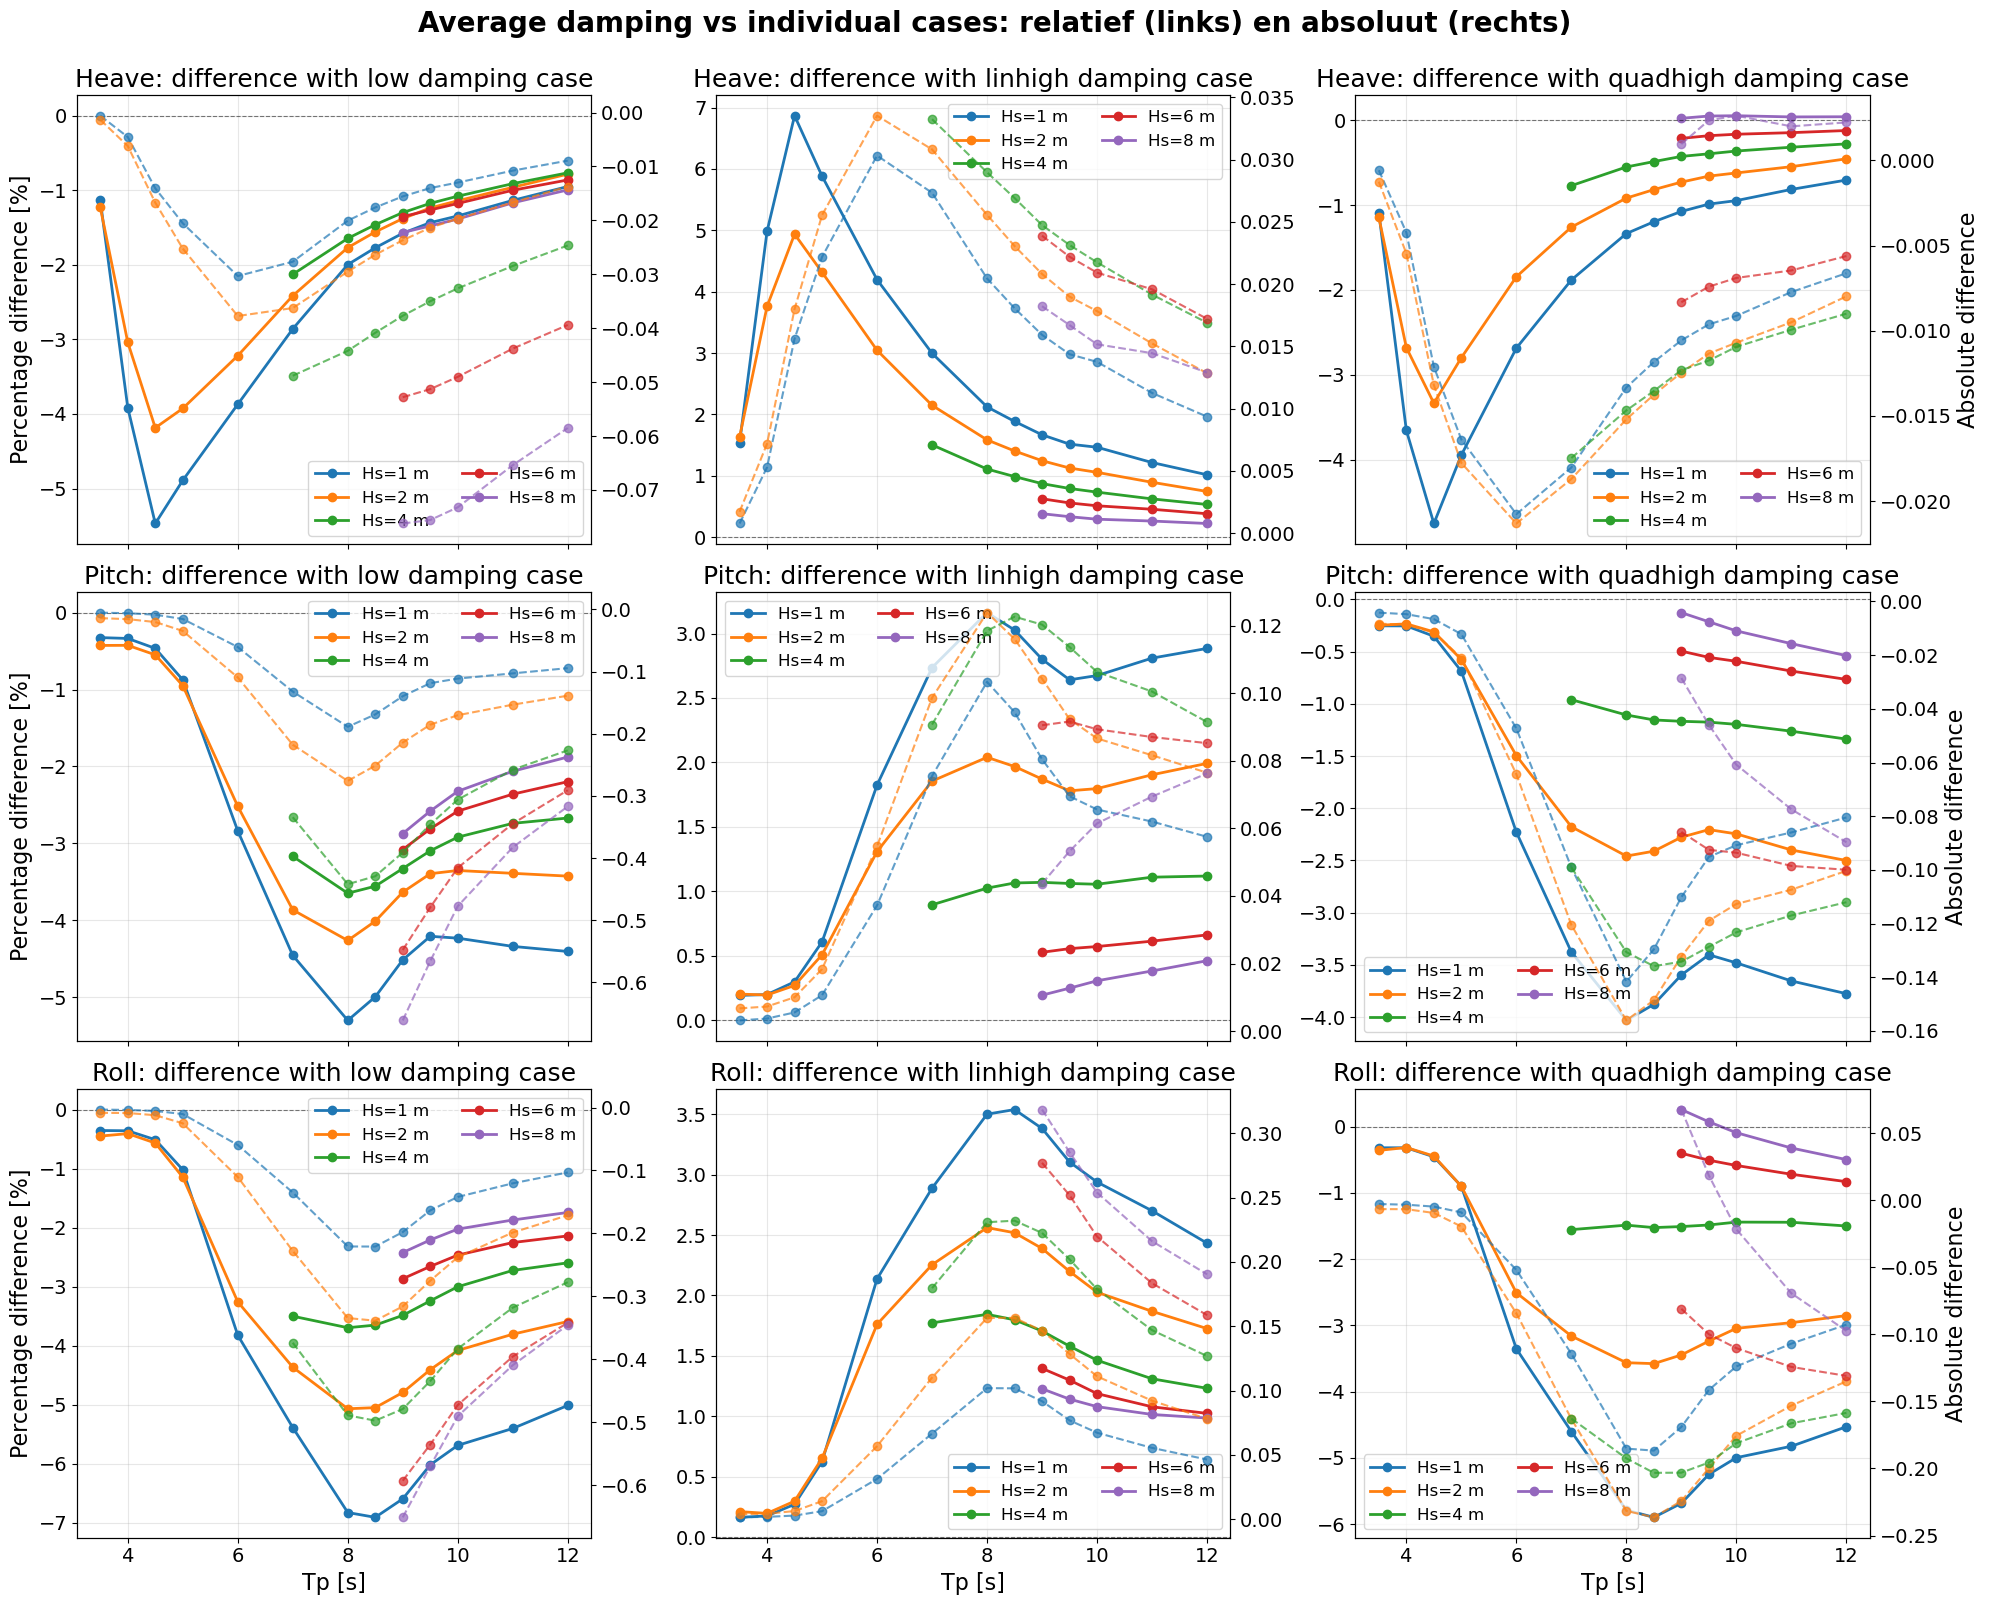

In [51]:
COMPARISONS = ['low', 'linhigh', 'quadhigh']

fig, axes = plt.subplots(3, 3, figsize=(20, 16), sharex=True)

for r, dof in enumerate(DOFS):
    sub_dof = filter_dirs(df, dof)
    dcol = damping_col(dof['key'])
    mpm_c = f'MPM {dof["key"]} corr'

    pivot = sub_dof.groupby([dcol, 'Hs', 'Tp'])[mpm_c].mean().unstack(dcol)
    if 'average' not in pivot.columns:
        continue
    avg = pivot['average']

    for c, other in enumerate(COMPARISONS):
        ax = axes[r, c]              # linker y-as: relatieve afname [%]
        if other not in pivot.columns:
            ax.set_visible(False)
            continue
        ax2 = ax.twinx()            # rechter y-as: absolute afname

        diff_abs = (avg - pivot[other]).rename('diff_abs').reset_index()
        diff_pct = ((avg - pivot[other]) / pivot[other] * 100).rename('diff').reset_index()

        for hs in HS_VALUES:
            s_pct = diff_pct[diff_pct['Hs'] == hs].sort_values('Tp')
            s_abs = diff_abs[diff_abs['Hs'] == hs].sort_values('Tp')
            if s_pct.empty:
                continue
            # relatief op linker-as
            line, = ax.plot(s_pct['Tp'], s_pct['diff'], 'o-', label=f'Hs={hs} m', linewidth=2)
            # absoluut op rechter-as, zelfde kleur
            ax2.plot(s_abs['Tp'], s_abs['diff_abs'], 'o--',
                     color=line.get_color(), linewidth=1.5, markersize=6, alpha=0.7)

        ax.axhline(0, color='black', lw=0.8, ls='--', alpha=0.5)
        ax.set_title(f'{dof["name"]}: difference with {other} damping case', fontsize=TITLE_SIZE)
        ax.tick_params(axis='both', labelsize=TICK_SIZE)
        ax2.tick_params(axis='y', labelsize=TICK_SIZE)
        ax.grid(True, alpha=0.3)
        if r == 2:
            ax.set_xlabel('Tp [s]', fontsize=LABEL_SIZE)
        if c == 0:
            ax.set_ylabel('Percentage difference [%]', fontsize=LABEL_SIZE)
        if c == 2:
            ax2.set_ylabel('Absolute difference', fontsize=LABEL_SIZE)
        ax.legend(fontsize=TICK_SIZE - 2, ncol=2)

fig.suptitle('Average damping vs individual cases: relatief (links) en absoluut (rechts)',
             y=1.00, fontsize=TITLE_SIZE + 2, fontweight='bold')
fig.tight_layout()
plt.show()

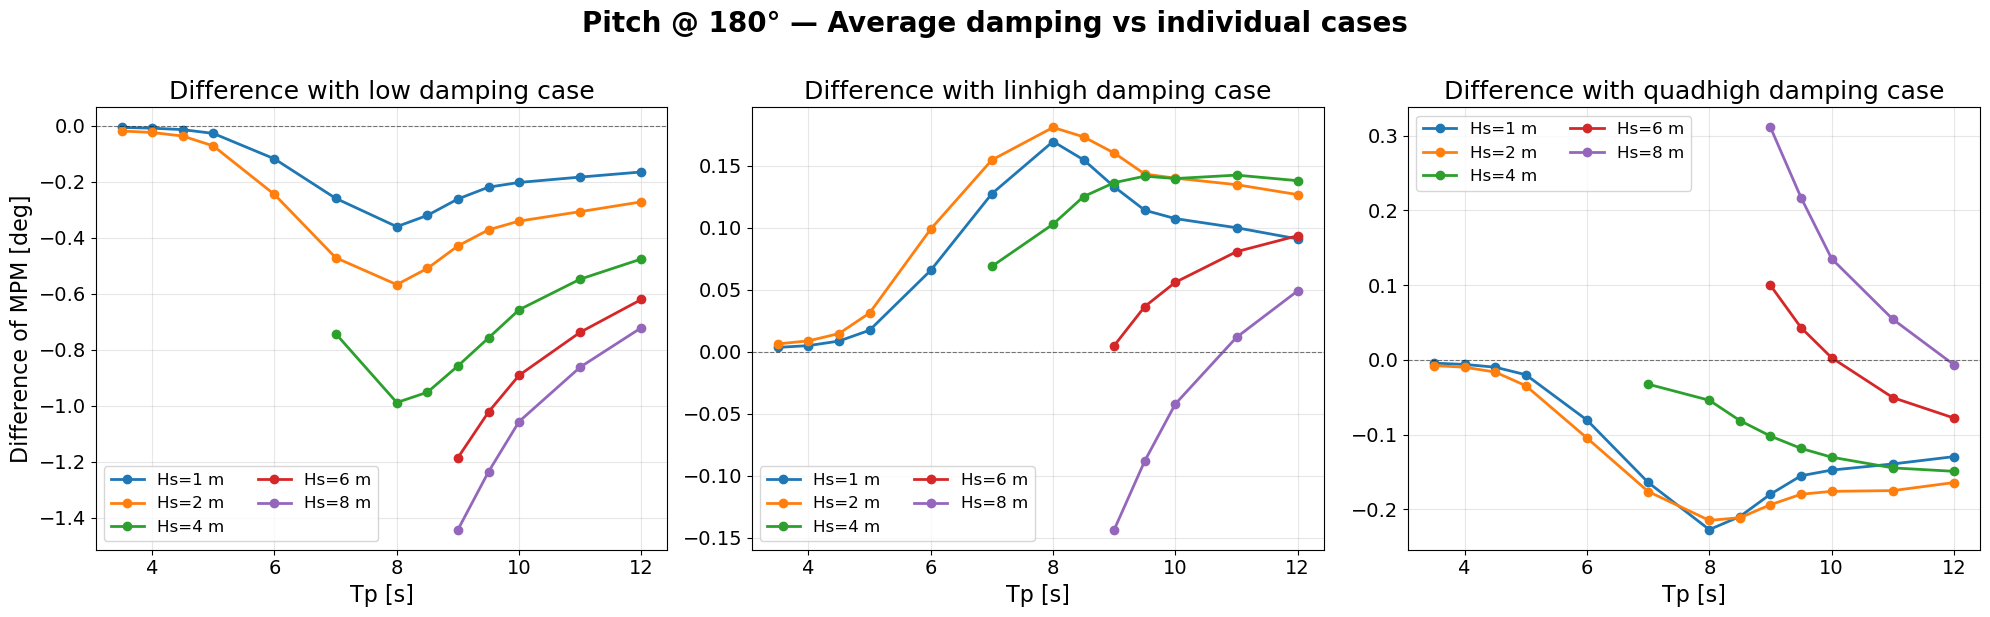

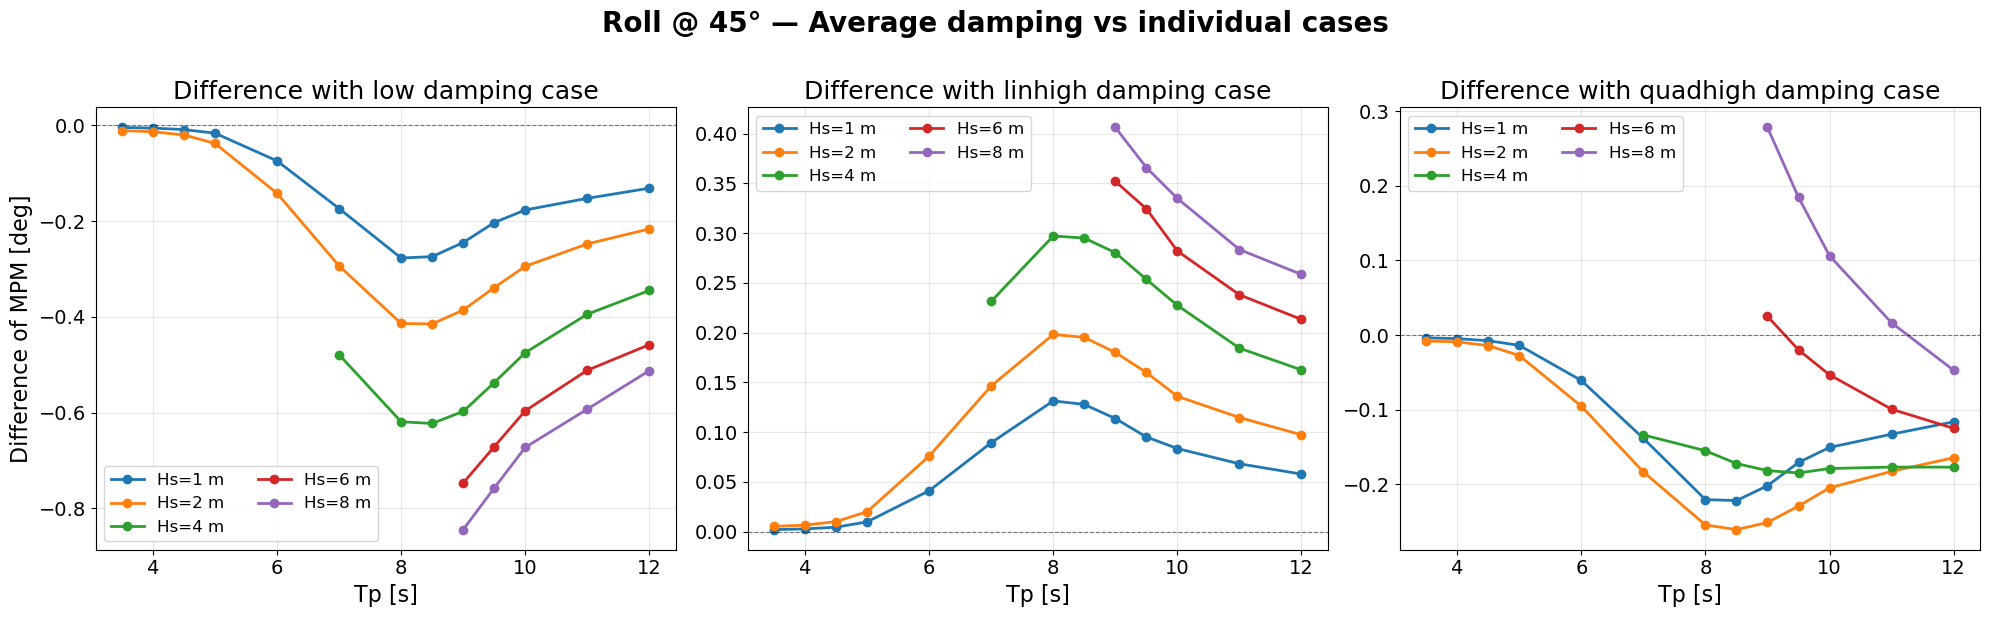

In [56]:
DIR_COL = 'Direction'   # <-- adjust to the actual wave direction column name

def plot_reduction(df, dof, wave_dir):
    sub_dof = filter_dirs(df, dof)
    sub_dof = sub_dof[sub_dof[DIR_COL] == wave_dir]
    dcol = damping_col(dof['key'])
    mpm_c = f'MPM {dof["key"]} corr'

    pivot = sub_dof.groupby([dcol, 'Hs', 'Tp'])[mpm_c].mean().unstack(dcol)
    if 'average' not in pivot.columns:
        print(f"No 'average' column for {dof['name']} @ {wave_dir}°")
        return None
    avg = pivot['average']

    fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharex=True)

    for c, other in enumerate(COMPARISONS):
        ax = axes[c]              # absolute difference
        if other not in pivot.columns:
            ax.set_visible(False)
            continue

        diff_abs = (avg - pivot[other]).rename('diff_abs').reset_index()

        for hs in HS_VALUES:
            s_abs = diff_abs[diff_abs['Hs'] == hs].sort_values('Tp')
            if s_abs.empty:
                continue
            ax.plot(s_abs['Tp'], s_abs['diff_abs'], 'o-', label=f'Hs={hs} m', linewidth=2)

        ax.axhline(0, color='black', lw=0.8, ls='--', alpha=0.5)
        ax.set_title(f'Difference with {other} damping case', fontsize=TITLE_SIZE)
        ax.tick_params(axis='both', labelsize=TICK_SIZE)
        ax.grid(True, alpha=0.3)
        ax.set_xlabel('Tp [s]', fontsize=LABEL_SIZE)
        if c == 0:
            ax.set_ylabel('Difference of MPM [deg]', fontsize=LABEL_SIZE)
        ax.legend(fontsize=TICK_SIZE - 2, ncol=2)

    fig.suptitle(f'{dof["name"]} @ {wave_dir}° — Average damping vs individual cases',
                 y=1.02, fontsize=TITLE_SIZE + 2, fontweight='bold')
    fig.tight_layout()
    return fig


# look up pitch DOF and roll DOF in DOFS
pitch_dof = next(d for d in DOFS if d['key'] == 'pitch')
roll_dof  = next(d for d in DOFS if d['key'] == 'roll')

plot_reduction(df, pitch_dof, 180)   # pitch at 180° wave direction
plot_reduction(df, roll_dof, 45)     # roll at 45° wave direction
plt.show()

## 8. Damping contribution vs platform motion

Quadratic damping force scales with velocity squared, so its effect should depend on **how much the platform moves**, not on Hs or Tp directly. Here each point is one (Hs, Tp, direction) condition. The x-axis is the platform motion magnitude (Std of the *low*-damping case, a measure independent of the chosen damping), and the y-axis is the MPM reduction vs low. If the claim holds, `quadhigh` (green) should reduce **more** as motion grows, while `linhigh` (orange) stays roughly flat or weakens.

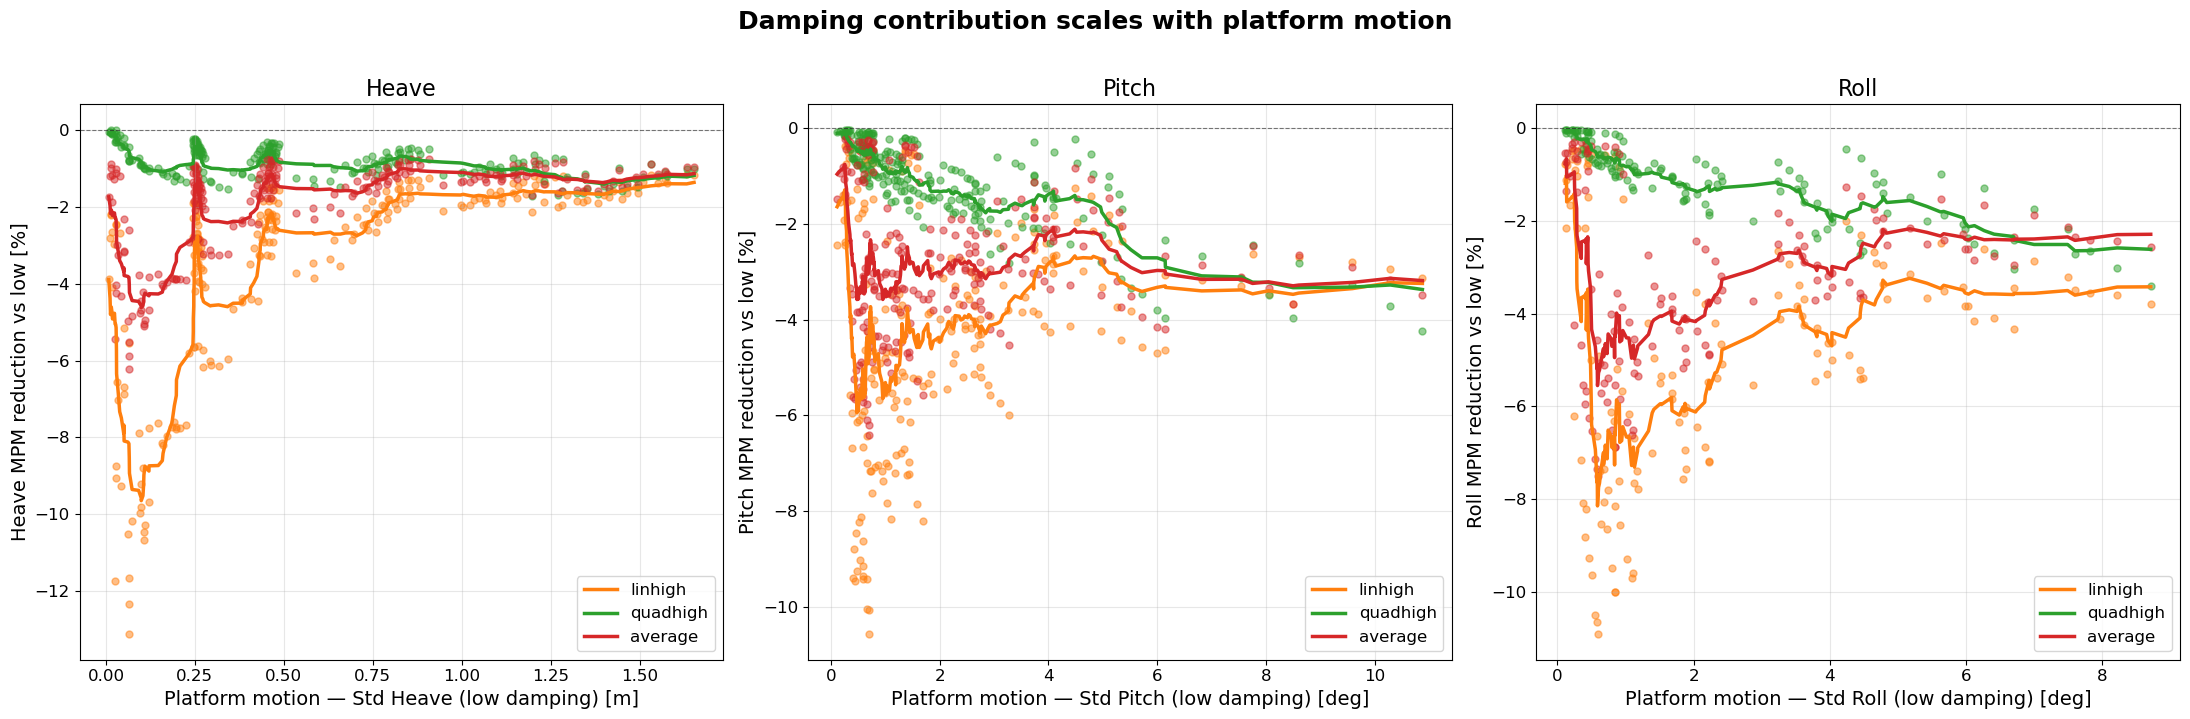

In [14]:
KEYS = ['Hs', 'Tp', 'Direction']

fig, axes = plt.subplots(1, 3, figsize=(22, 7))

for ax, dof in zip(axes, DOFS):
    sub_dof = filter_dirs(df, dof)
    dcol = damping_col(dof['key'])
    mpm_c = f'MPM {dof["key"]} corr'
    std_c = f'Std {dof["key"]}'

    low = sub_dof[sub_dof[dcol] == 'low'].set_index(KEYS)

    for case in ['linhigh', 'quadhigh', 'average']:
        cur = sub_dof[sub_dof[dcol] == case].set_index(KEYS)
        common = cur.index.intersection(low.index)
        if len(common) == 0:
            continue
        x = low.loc[common, std_c].values
        y = ((cur.loc[common, mpm_c] - low.loc[common, mpm_c])
             / low.loc[common, mpm_c] * 100).values
        order = np.argsort(x)
        ax.scatter(x, y, s=25, alpha=0.5, color=DAMPING_COLORS[case])
        # trend line (rolling mean over sorted x)
        xs, ys = x[order], y[order]
        if len(xs) >= 8:
            w = max(5, len(xs)//12)
            trend = pd.Series(ys).rolling(w, center=True, min_periods=1).mean().values
            ax.plot(xs, trend, '-', color=DAMPING_COLORS[case],
                    linewidth=2.5, label=case)
        else:
            ax.plot(xs, ys, '-', color=DAMPING_COLORS[case],
                    linewidth=2.5, label=case)

    ax.axhline(0, color='black', lw=0.8, ls='--', alpha=0.5)
    ax.set_xlabel(f'Platform motion — Std {dof["name"]} (low damping) [{dof["unit"]}]',
                  fontsize=LABEL_SIZE)
    ax.set_ylabel(f'{dof["name"]} MPM reduction vs low [%]', fontsize=LABEL_SIZE)
    ax.set_title(dof['name'], fontsize=TITLE_SIZE)
    ax.tick_params(axis='both', labelsize=TICK_SIZE)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=TICK_SIZE)

fig.suptitle('Damping contribution scales with platform motion',
             y=1.02, fontsize=TITLE_SIZE + 2, fontweight='bold')
fig.tight_layout()
plt.show()

### 8b. Does the quadratic reduction collapse onto a single motion curve?

Same axes as above but only `quadhigh`, with points coloured by Hs. If the damping contribution is governed by platform motion alone (and not Hs or Tp separately), points from all sea states should fall on **one** common curve. Spread between colours at the same x means motion magnitude is not the whole story (frequency content also matters for a velocity-squared term).

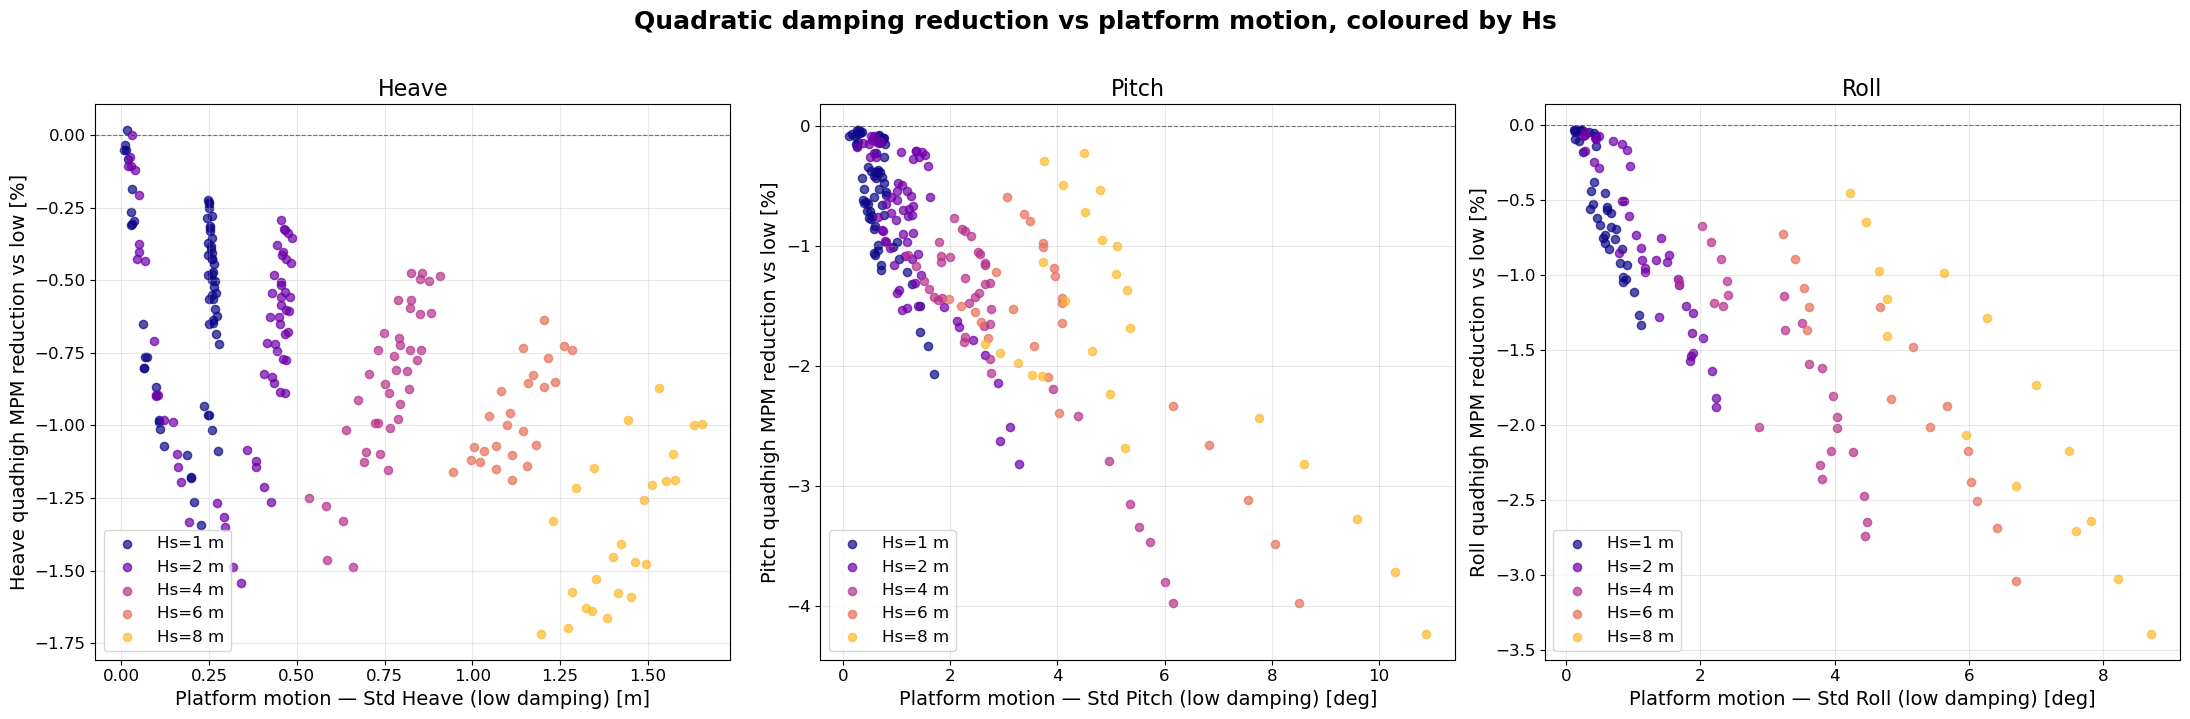

In [15]:
KEYS = ['Hs', 'Tp', 'Direction']
HS_CMAP = plt.cm.plasma(np.linspace(0, 0.85, len(HS_VALUES)))
HS_COLOR = {hs: HS_CMAP[i] for i, hs in enumerate(HS_VALUES)}

fig, axes = plt.subplots(1, 3, figsize=(22, 7))

for ax, dof in zip(axes, DOFS):
    sub_dof = filter_dirs(df, dof)
    dcol = damping_col(dof['key'])
    mpm_c = f'MPM {dof["key"]} corr'
    std_c = f'Std {dof["key"]}'

    low = sub_dof[sub_dof[dcol] == 'low'].set_index(KEYS)
    cur = sub_dof[sub_dof[dcol] == 'quadhigh'].set_index(KEYS)
    common = cur.index.intersection(low.index)

    x = low.loc[common, std_c]
    y = (cur.loc[common, mpm_c] - low.loc[common, mpm_c]) / low.loc[common, mpm_c] * 100
    hs_idx = common.get_level_values('Hs')

    for hs in HS_VALUES:
        m = hs_idx == hs
        if not m.any():
            continue
        ax.scatter(x[m], y[m], s=35, alpha=0.7,
                   color=HS_COLOR[hs], label=f'Hs={hs} m')

    ax.axhline(0, color='black', lw=0.8, ls='--', alpha=0.5)
    ax.set_xlabel(f'Platform motion — Std {dof["name"]} (low damping) [{dof["unit"]}]',
                  fontsize=LABEL_SIZE)
    ax.set_ylabel(f'{dof["name"]} quadhigh MPM reduction vs low [%]', fontsize=LABEL_SIZE)
    ax.set_title(dof['name'], fontsize=TITLE_SIZE)
    ax.tick_params(axis='both', labelsize=TICK_SIZE)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=TICK_SIZE)

fig.suptitle('Quadratic damping reduction vs platform motion, coloured by Hs',
             y=1.02, fontsize=TITLE_SIZE + 2, fontweight='bold')
fig.tight_layout()
plt.show()

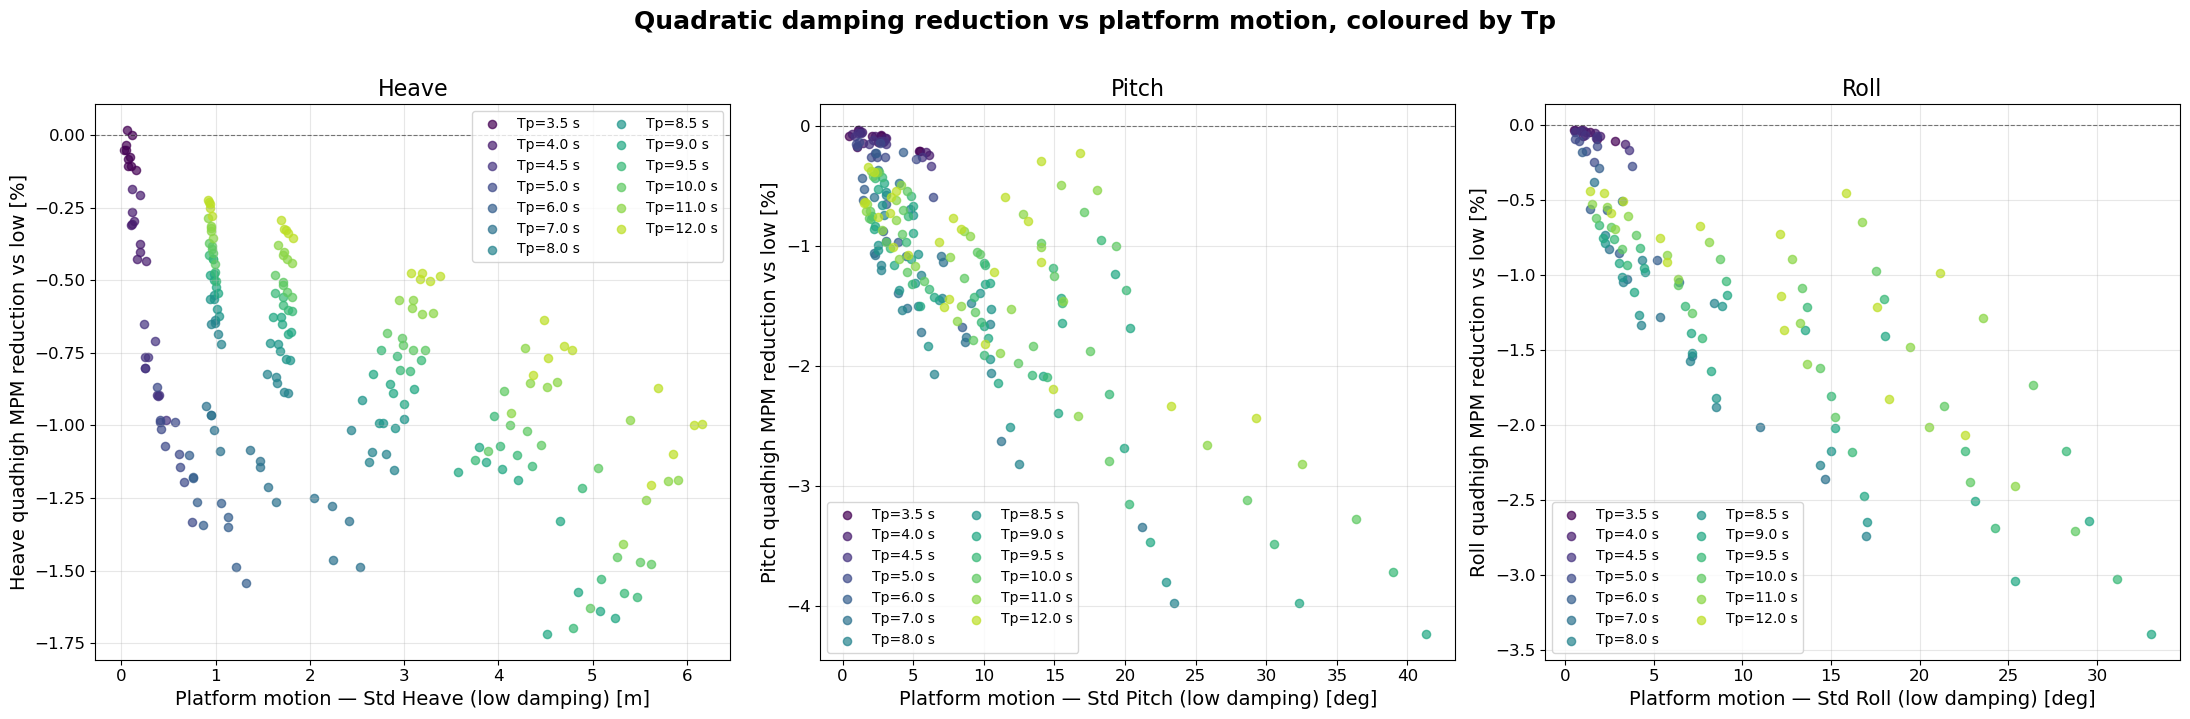

In [16]:
KEYS = ['Hs', 'Tp', 'Direction']
TP_VALUES = sorted(df['Tp'].unique())
TP_CMAP = plt.cm.viridis(np.linspace(0, 0.9, len(TP_VALUES)))
TP_COLOR = {tp: TP_CMAP[i] for i, tp in enumerate(TP_VALUES)}

fig, axes = plt.subplots(1, 3, figsize=(22, 7))

for ax, dof in zip(axes, DOFS):
    sub_dof = filter_dirs(df, dof)
    dcol = damping_col(dof['key'])
    mpm_c = f'MPM {dof["key"]} corr'
    std_c = f'Std {dof["key"]}'

    low = sub_dof[sub_dof[dcol] == 'low'].set_index(KEYS)
    cur = sub_dof[sub_dof[dcol] == 'quadhigh'].set_index(KEYS)
    common = cur.index.intersection(low.index)

    x = low.loc[common, mpm_c]
    y = (cur.loc[common, mpm_c] - low.loc[common, mpm_c]) / low.loc[common, mpm_c] * 100
    # y = (cur.loc[common, std_c] - low.loc[common, std_c]) / low.loc[common, std_c] * 100
    tp_idx = common.get_level_values('Tp')

    for tp in TP_VALUES:
        m = tp_idx == tp
        if not m.any():
            continue
        ax.scatter(x[m], y[m], s=35, alpha=0.7,
                   color=TP_COLOR[tp], label=f'Tp={tp} s')

    ax.axhline(0, color='black', lw=0.8, ls='--', alpha=0.5)
    ax.set_xlabel(f'Platform motion — Std {dof["name"]} (low damping) [{dof["unit"]}]',
                  fontsize=LABEL_SIZE)
    ax.set_ylabel(f'{dof["name"]} quadhigh MPM reduction vs low [%]', fontsize=LABEL_SIZE)
    ax.set_title(dof['name'], fontsize=TITLE_SIZE)
    ax.tick_params(axis='both', labelsize=TICK_SIZE)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=TICK_SIZE - 2, ncol=2)

fig.suptitle('Quadratic damping reduction vs platform motion, coloured by Tp',
             y=1.02, fontsize=TITLE_SIZE + 2, fontweight='bold')
fig.tight_layout()
plt.show()

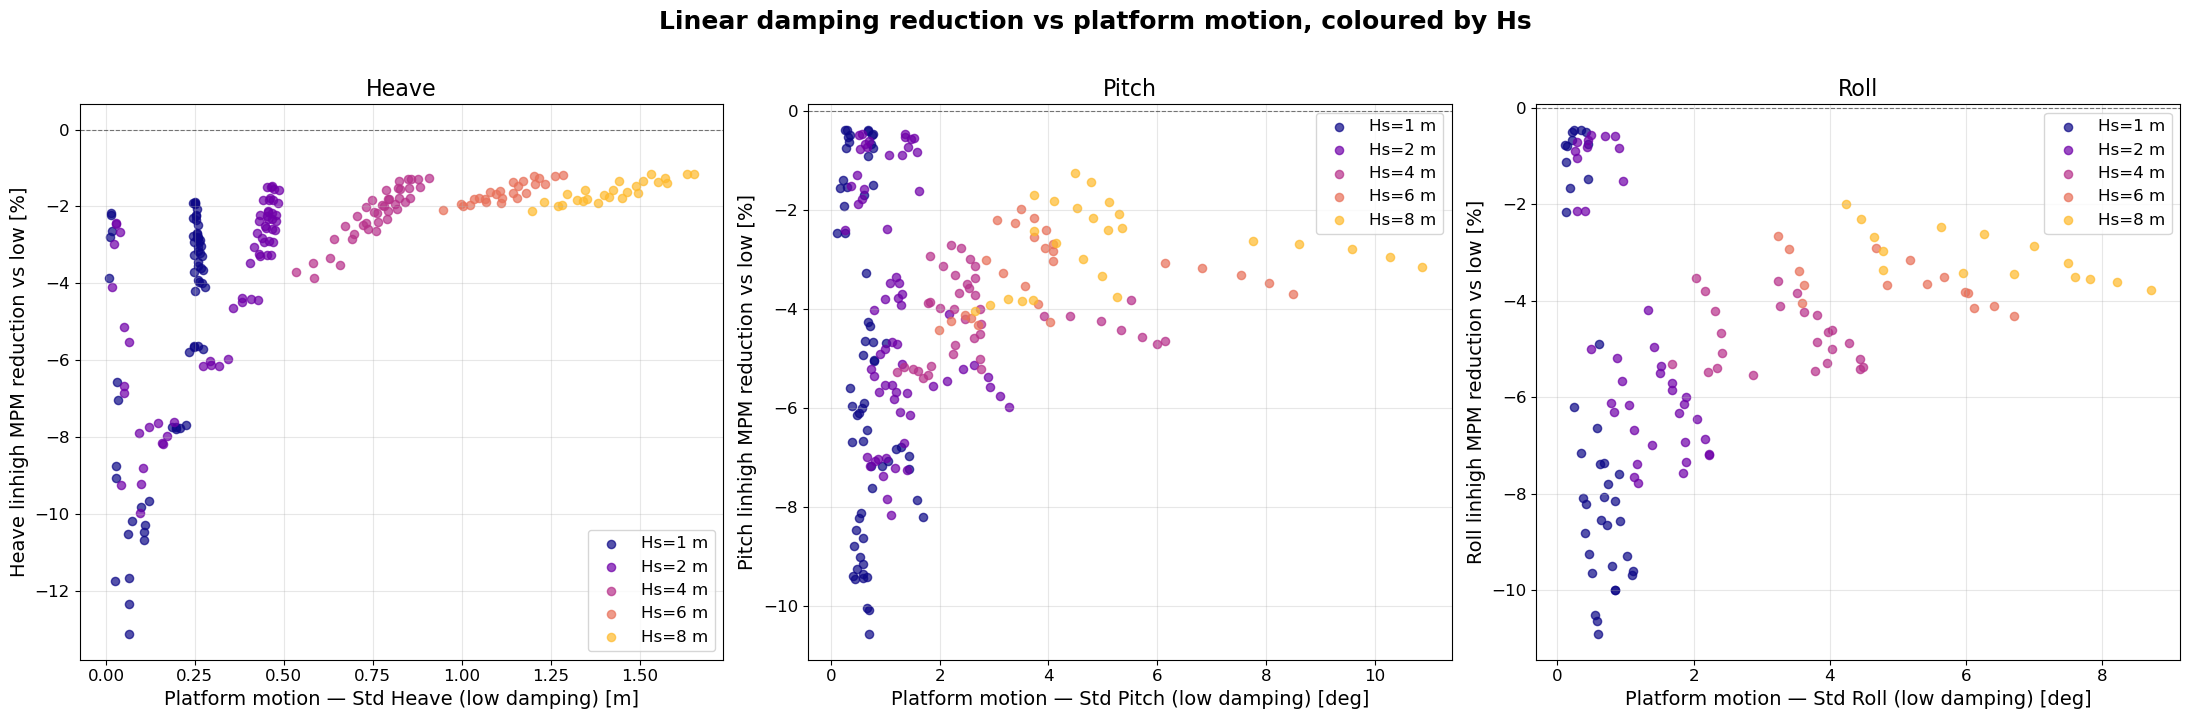

In [17]:
KEYS = ['Hs', 'Tp', 'Direction']
HS_CMAP = plt.cm.plasma(np.linspace(0, 0.85, len(HS_VALUES)))
HS_COLOR = {hs: HS_CMAP[i] for i, hs in enumerate(HS_VALUES)}

fig, axes = plt.subplots(1, 3, figsize=(22, 7))

for ax, dof in zip(axes, DOFS):
    sub_dof = filter_dirs(df, dof)
    dcol = damping_col(dof['key'])
    mpm_c = f'MPM {dof["key"]} corr'
    std_c = f'Std {dof["key"]}'

    low = sub_dof[sub_dof[dcol] == 'low'].set_index(KEYS)
    cur = sub_dof[sub_dof[dcol] == 'linhigh'].set_index(KEYS)
    common = cur.index.intersection(low.index)

    x = low.loc[common, std_c]
    y = (cur.loc[common, mpm_c] - low.loc[common, mpm_c]) / low.loc[common, mpm_c] * 100
    hs_idx = common.get_level_values('Hs')

    for hs in HS_VALUES:
        m = hs_idx == hs
        if not m.any():
            continue
        ax.scatter(x[m], y[m], s=35, alpha=0.7,
                   color=HS_COLOR[hs], label=f'Hs={hs} m')

    ax.axhline(0, color='black', lw=0.8, ls='--', alpha=0.5)
    ax.set_xlabel(f'Platform motion — Std {dof["name"]} (low damping) [{dof["unit"]}]',
                  fontsize=LABEL_SIZE)
    ax.set_ylabel(f'{dof["name"]} linhigh MPM reduction vs low [%]', fontsize=LABEL_SIZE)
    ax.set_title(dof['name'], fontsize=TITLE_SIZE)
    ax.tick_params(axis='both', labelsize=TICK_SIZE)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=TICK_SIZE)

fig.suptitle('Linear damping reduction vs platform motion, coloured by Hs',
             y=1.02, fontsize=TITLE_SIZE + 2, fontweight='bold')
fig.tight_layout()
plt.show()

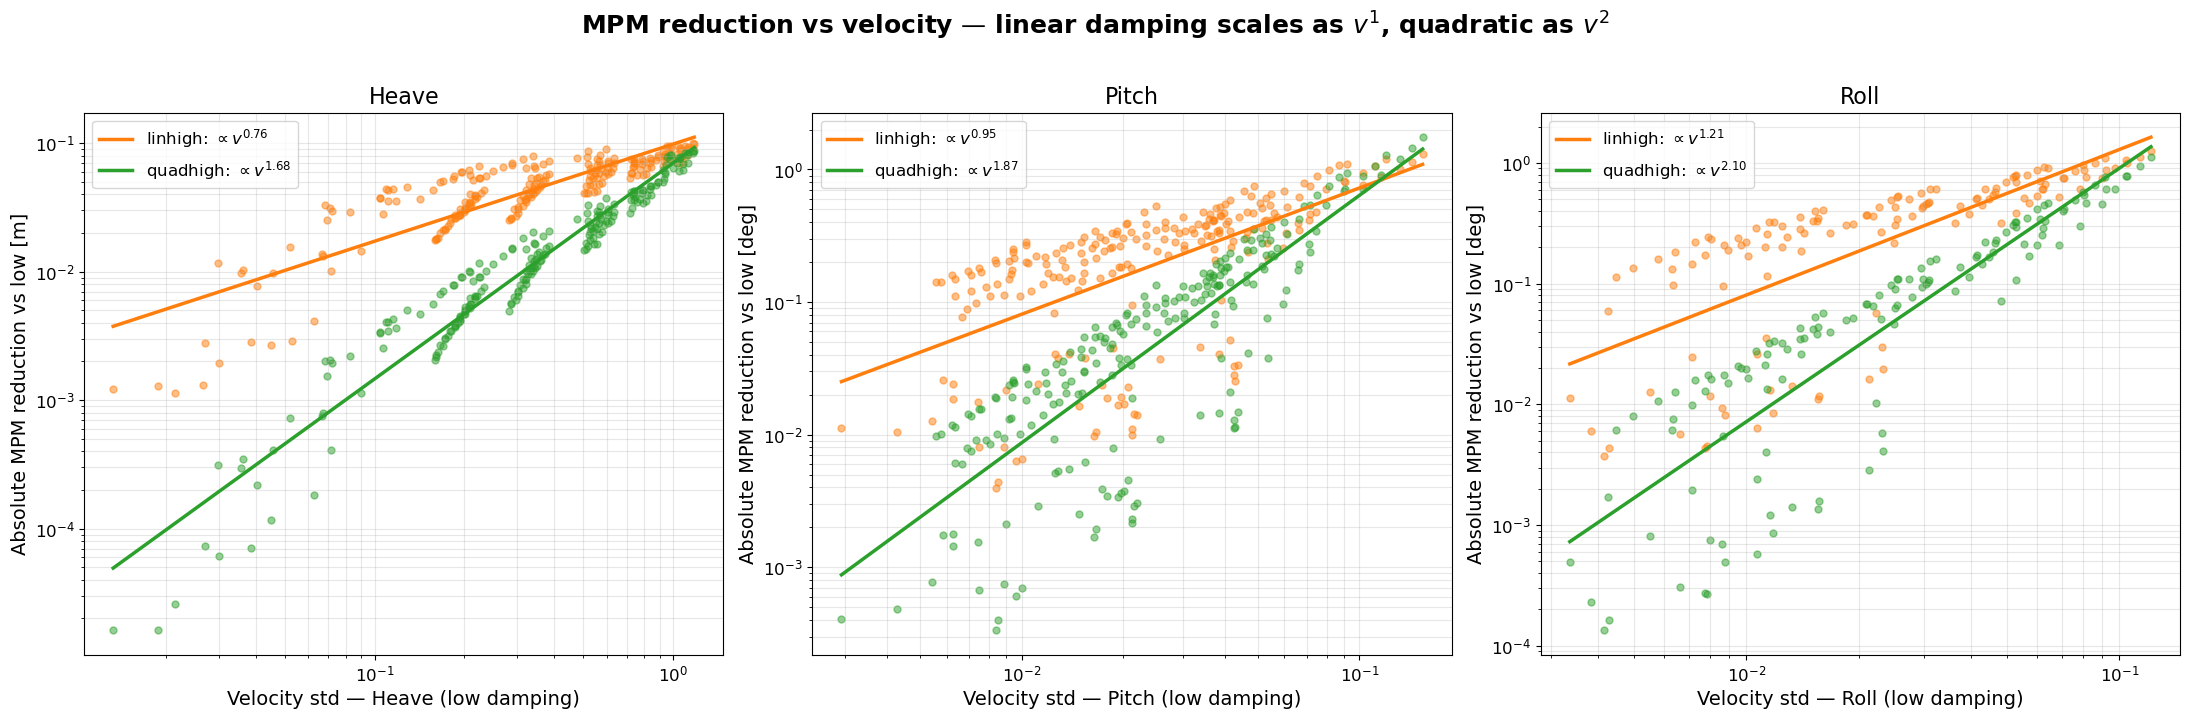

In [18]:

KEYS = ['Hs', 'Tp', 'Direction']

# velocity column per DOF
VCOL = {'Z': 'std velocity Z', 'pitch': 'std velocity pitch', 'roll': 'std velocity roll'}

fig, axes = plt.subplots(1, 3, figsize=(22, 7))

for ax, dof in zip(axes, DOFS):
    sub_dof = filter_dirs(df, dof)
    dcol = damping_col(dof['key'])
    mpm_c = f'MPM {dof["key"]} corr'
    vcol = VCOL[dof['key']]

    low = sub_dof[sub_dof[dcol] == 'low'].set_index(KEYS)

    for case in ['linhigh', 'quadhigh']:
        cur = sub_dof[sub_dof[dcol] == case].set_index(KEYS)
        common = cur.index.intersection(low.index)
        v = low.loc[common, vcol].values
        # absolute MPM reduction vs low (positive = improvement)
        dred = (low.loc[common, mpm_c] - cur.loc[common, mpm_c]).values
        mask = (v > 0) & (dred > 0)

        ax.scatter(v[mask], dred[mask], s=25, alpha=0.5, color=DAMPING_COLORS[case])

        # power-law fit in log-log space: dred = a * v^b
        b, loga = np.polyfit(np.log(v[mask]), np.log(dred[mask]), 1)
        xx = np.linspace(v[mask].min(), v[mask].max(), 50)
        ax.plot(xx, np.exp(loga) * xx**b, '-', color=DAMPING_COLORS[case],
                linewidth=2.5, label=f'{case}: $\\propto v^{{{b:.2f}}}$')

    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel(f'Velocity std — {dof["name"]} (low damping)', fontsize=LABEL_SIZE)
    ax.set_ylabel(f'Absolute MPM reduction vs low [{dof["unit"]}]', fontsize=LABEL_SIZE)
    ax.set_title(dof['name'], fontsize=TITLE_SIZE)
    ax.tick_params(axis='both', labelsize=TICK_SIZE)
    ax.grid(True, alpha=0.3, which='both')
    ax.legend(fontsize=TICK_SIZE)

fig.suptitle('MPM reduction vs velocity — linear damping scales as $v^1$, quadratic as $v^2$',
             y=1.02, fontsize=TITLE_SIZE + 2, fontweight='bold')
fig.tight_layout()
plt.show()

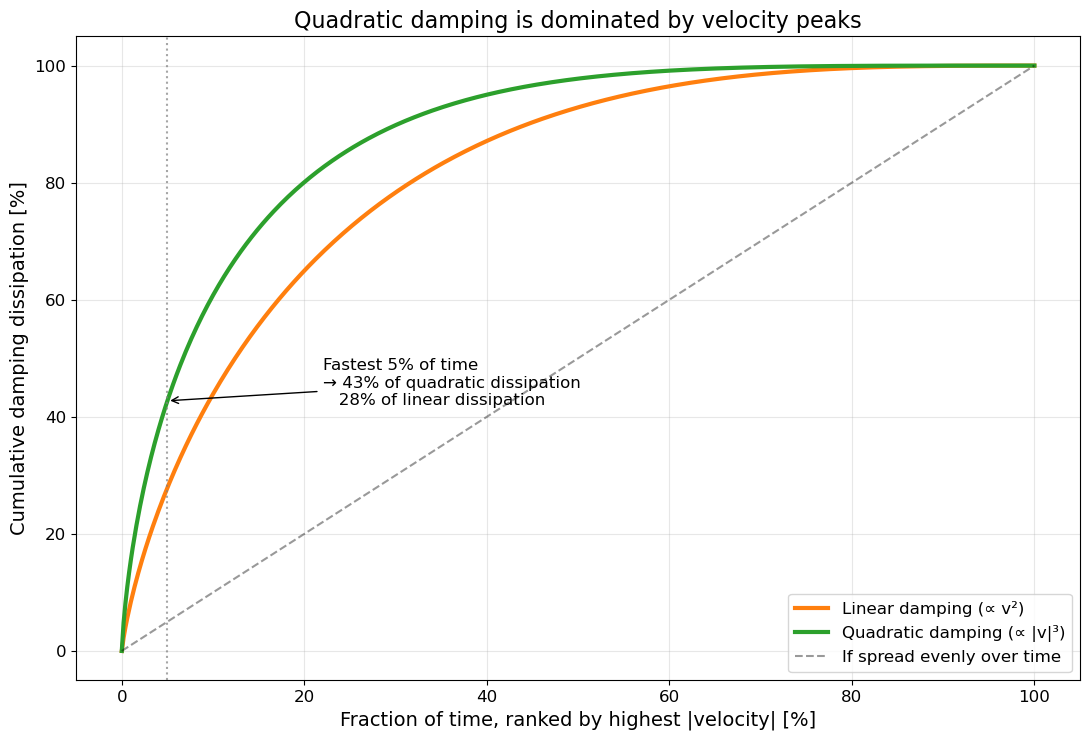

In [19]:
# How concentrated is damping dissipation in the velocity peaks?
# For a narrow-band Gaussian velocity signal v ~ N(0, sigma):
#   linear dissipation per cycle ~ integral of v^2
#   quadratic dissipation per cycle ~ integral of |v|^3
# We rank time by |v| and show how much dissipation comes from the fastest moments.

N = 3_000_000
v = np.abs(np.random.normal(0, 1, N))
vs = np.sort(v)[::-1]                       # high to low
frac_time = np.arange(1, N + 1) / N
cum_v2 = np.cumsum(vs**2) / np.sum(vs**2)   # linear
cum_v3 = np.cumsum(vs**3) / np.sum(vs**3)   # quadratic
idx = np.linspace(0, N - 1, 500).astype(int)

fig, ax = plt.subplots(figsize=(11, 7.5))
ax.plot(frac_time[idx] * 100, cum_v2[idx] * 100, color=DAMPING_COLORS['linhigh'],
        linewidth=3, label='Linear damping (∝ v²)')
ax.plot(frac_time[idx] * 100, cum_v3[idx] * 100, color=DAMPING_COLORS['quadhigh'],
        linewidth=3, label='Quadratic damping (∝ |v|³)')
ax.plot([0, 100], [0, 100], 'k--', alpha=0.4, label='If spread evenly over time')

ax.axvline(5, color='gray', ls=':', alpha=0.7)
i5 = np.argmin(np.abs(frac_time - 0.05))
ax.annotate(f'Fastest 5% of time\n→ {cum_v3[i5]*100:.0f}% of quadratic dissipation\n   {cum_v2[i5]*100:.0f}% of linear dissipation',
            xy=(5, cum_v3[i5] * 100), xytext=(22, 42), fontsize=TICK_SIZE,
            arrowprops=dict(arrowstyle='->', color='black'))

ax.set_xlabel('Fraction of time, ranked by highest |velocity| [%]', fontsize=LABEL_SIZE)
ax.set_ylabel('Cumulative damping dissipation [%]', fontsize=LABEL_SIZE)
ax.set_title('Quadratic damping is dominated by velocity peaks', fontsize=TITLE_SIZE)
ax.tick_params(labelsize=TICK_SIZE)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=TICK_SIZE, loc='lower right')
fig.tight_layout()
plt.show()

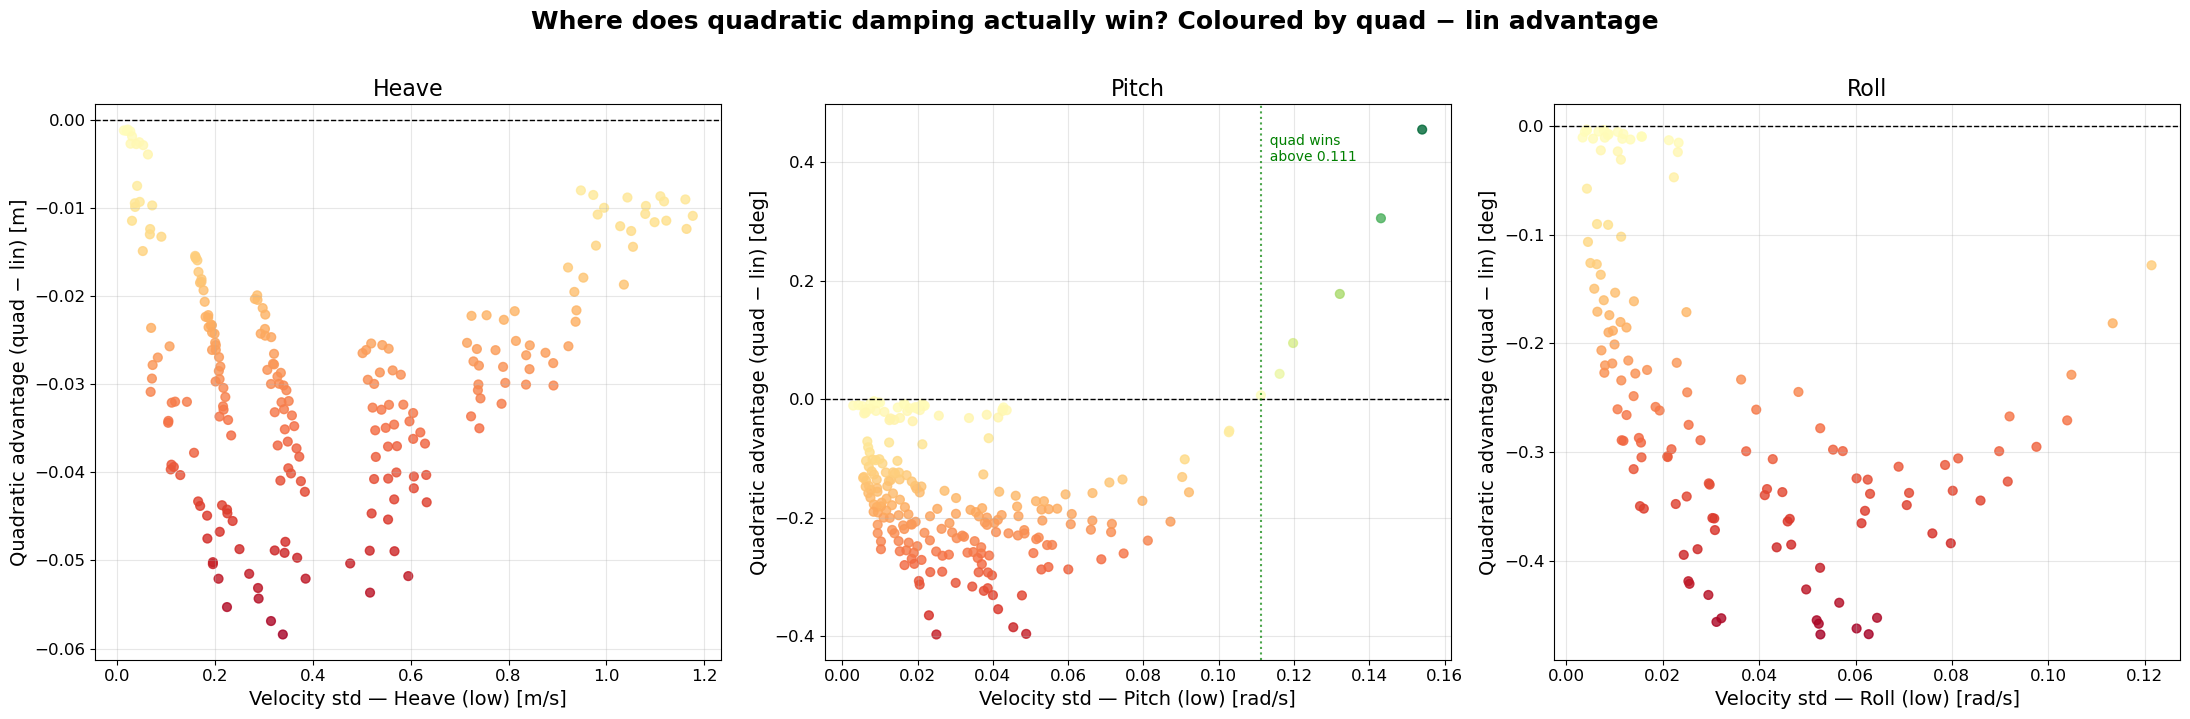

In [20]:
KEYS = ['Hs', 'Tp', 'Direction']
VCOL = {'Z': 'std velocity Z', 'pitch': 'std velocity pitch', 'roll': 'std velocity roll'}
VUNIT = {'Z': 'm/s', 'pitch': 'rad/s', 'roll': 'rad/s'}

fig, axes = plt.subplots(1, 3, figsize=(22, 7))

for ax, dof in zip(axes, DOFS):
    sub_dof = filter_dirs(df, dof)
    dcol = damping_col(dof['key'])
    mpm_c = f'MPM {dof["key"]} corr'
    vcol = VCOL[dof['key']]

    low  = sub_dof[sub_dof[dcol] == 'low'].set_index(KEYS)
    lin  = sub_dof[sub_dof[dcol] == 'linhigh'].set_index(KEYS)
    quad = sub_dof[sub_dof[dcol] == 'quadhigh'].set_index(KEYS)
    common = quad.index.intersection(low.index).intersection(lin.index)

    v = low.loc[common, vcol].values
    red_lin  = (low.loc[common, mpm_c] - lin.loc[common, mpm_c]).values
    red_quad = (low.loc[common, mpm_c] - quad.loc[common, mpm_c]).values
    advantage = red_quad - red_lin   # positive = quadratic wins

    vmax = np.abs(advantage).max()
    sc = ax.scatter(v, advantage, c=advantage, cmap='RdYlGn', s=40, alpha=0.8,
                    vmin=-vmax, vmax=vmax)
    ax.axhline(0, color='black', lw=1, ls='--')

    # crossover velocity (first v where advantage turns positive)
    above = v[advantage > 0]
    if len(above):
        ax.axvline(above.min(), color='green', ls=':', alpha=0.7)
        ax.text(above.min(), ax.get_ylim()[1]*0.9, f'  quad wins\n  above {above.min():.3f}',
                fontsize=TICK_SIZE - 2, color='green', va='top')

    ax.set_xlabel(f'Velocity std — {dof["name"]} (low) [{VUNIT[dof["key"]]}]', fontsize=LABEL_SIZE)
    ax.set_ylabel(f'Quadratic advantage (quad − lin) [{dof["unit"]}]', fontsize=LABEL_SIZE)
    ax.set_title(dof['name'], fontsize=TITLE_SIZE)
    ax.tick_params(labelsize=TICK_SIZE)
    ax.grid(True, alpha=0.3)

fig.suptitle('Where does quadratic damping actually win? Coloured by quad − lin advantage',
             y=1.02, fontsize=TITLE_SIZE + 2, fontweight='bold')
fig.tight_layout()
plt.show()